In [4]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import joblib
import json
import time
import shap

from FuncionesAUX import *
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve

In [5]:
# RUTAS DE TRABAJO
BASE = Path(r"C:\Users\Gambo\Documents\Master Aaron\TFM UCM")
DATA = BASE / "Data"

ruta_firespain = DATA / "firespain025_WGS84.nc"
ruta_era5 = DATA / "era5" / "era5_land_clean.nc"
ruta_mdt = DATA / "MDT" / "mdt_spain.tif"
ruta_civio = DATA / "CIVIO" / "fires-all.csv"
ruta_dataset_maestro = DATA / "dataset_maestro.parquet"

# CARGA Y VALIDACIÓN

In [6]:
df = pd.read_parquet(ruta_dataset_maestro)
df["anio"] = df["time"].dt.year

print_header("MODELO - VERIFICACIÓN DEL PERIODO DE MODELADO")
print(f"Rango temporal: desde {df.time.min()} hasta {df.time.max()}")
conteo_anual = (
    df.groupby("anio")
      .agg(
          filas=("anio","size"),
          dias=("time","nunique")))

display(conteo_anual)

dias_2022 = conteo_anual.loc[2022,"dias"]
print(f"\nDías disponibles en 2022: {dias_2022}")

MODELO - VERIFICACIÓN DEL PERIODO DE MODELADO
Rango temporal: desde 2008-01-01 00:00:00 hasta 2022-01-01 00:00:00


,filas,dias
anio,,
2008,299022,366
2009,298205,365
2010,298205,365
2011,298205,365
2012,299022,366
2013,298205,365
2014,298205,365
2015,298205,365
2016,299022,366



Días disponibles en 2022: 1


Exclusión del día suelto de 2022 porque no constituye un año utilizable para evaluación — se descarta
explícitamente del dataset de modelado

In [7]:
n_antes = len(df)
df_modelado = df[df["anio"] <= 2021].copy()
print(f"Filas excluidas por ser 2022 (día suelto): {n_antes - len(df_modelado):,}")
print(f"Filas en dataset de modelado: {len(df_modelado):,}")
print(f"Años disponibles: {sorted(df_modelado['anio'].unique())}")

Filas excluidas por ser 2022 (día suelto): 817
Filas en dataset de modelado: 4,178,138
Años disponibles: [np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]


In [8]:
folds = []
tabla = []

for fold, anio_val in enumerate(range(2014,2021), start=1):
    train_years = list(range(2008,anio_val))
    train = df_modelado[df_modelado.anio.isin(train_years)]
    val   = df_modelado[df_modelado.anio==anio_val]
    folds.append({...})

    tabla.append({
        "Fold":             fold,
        "Train":            f"{train_years[0]}-{train_years[-1]}",
        "Validación":       anio_val,
        "Años train":       len(train_years),
        "Filas train":      len(train),
        "Filas val":        len(val),
        "Prev train (%)":   train.target_incendio.mean()*100,
        "Prev val (%)":     val.target_incendio.mean()*100
        })

tabla_folds = pd.DataFrame(tabla)
print_header("MODELO - WALK/FORWARD")
display(tabla_folds.round(3))

MODELO - WALK/FORWARD


,Fold,Train,Validación,Años train,Filas train,Filas val,Prev train (%),Prev val (%)
0,1,2008-2013,2014,6,1790864,298205,2.990,2.344
1,2,2008-2014,2015,7,2089069,298205,2.898,2.789
2,3,2008-2015,2016,8,2387274,299022,2.884,2.190
3,4,2008-2016,2017,9,2686296,298205,2.807,1.385
4,5,2008-2017,2018,10,2984501,298205,2.665,0.751
5,6,2008-2018,2019,11,3282706,298205,2.491,0.640
6,7,2008-2019,2020,12,3580911,299022,2.337,0.358


El primer fold comienza en 2014 para garantizar que el modelo disponga de seis años completos de entrenamiento inicial, incluyendo suficiente variabilidad climática e interanual.

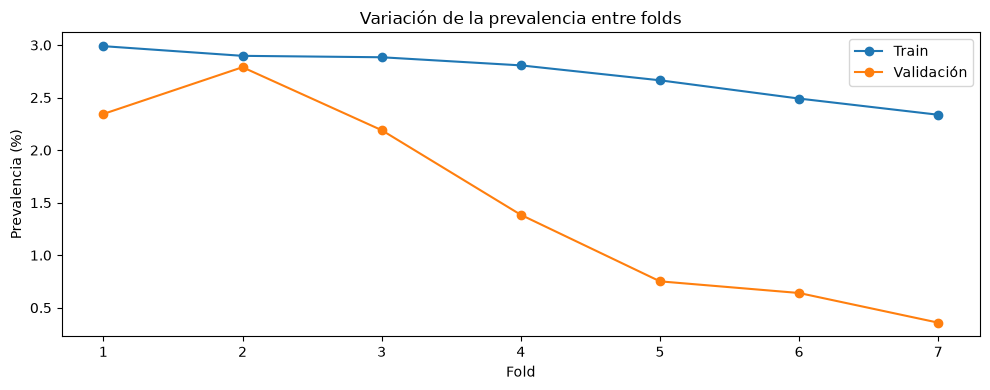

In [9]:
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(
    tabla_folds["Fold"],
    tabla_folds["Prev train (%)"],
    marker="o",
    label="Train"
)

ax.plot(
    tabla_folds["Fold"],
    tabla_folds["Prev val (%)"],
    marker="o",
    label="Validación"
)

ax.set_xlabel("Fold")
ax.set_ylabel("Prevalencia (%)")
ax.set_title("Variación de la prevalencia entre folds")

ax.legend()
save_figure("walkforward_prevalencia")

La figura evidencia un cambio progresivo en la prevalencia del target a lo largo del periodo de estudio. Mientras que entre 2008 y 2015 la prevalencia se mantiene alrededor del 2–3 %, a partir de 2016 comienza un descenso sostenido que culmina en 2021 con el valor mínimo de toda la serie (0,13 %)

Esta evolución indica que la distribución de entrenamiento no puede considerarse estacionaria, por lo que un esquema de validación aleatorio introduciría información de regímenes temporales futuros dentro del entrenamiento y produciría estimaciones excesivamente optimistas del rendimiento esperado

In [10]:
# ============================================================
# VERIFICACIÓN — ¿LA CAÍDA DE PREVALENCIA ES TENDENCIA REAL
# O ARTEFACTO DE REGISTRO?
# Contrastamos la prevalencia anual con el área quemada total
# (ya calculada en 03) y con si existe una tendencia lineal
# estadísticamente significativa, no solo "variabilidad".
# ============================================================
prevalencia_anual = df_modelado.groupby("anio")["target_incendio"].mean() * 100
ba_anual = df_modelado.groupby("anio")["target_ba"].sum()

print("="*60)
print("PREVALENCIA Y ÁREA QUEMADA POR AÑO")
print("="*60)
resumen = pd.DataFrame({"prevalencia_%": prevalencia_anual, "ba_total_ha": ba_anual})
print(resumen)

# Test de tendencia lineal (¿es estadísticamente significativa la caída?)
anios = resumen.index.values
slope, intercept, r_value, p_value, std_err = stats.linregress(anios, resumen["prevalencia_%"])
print(f"\nTendencia lineal de prevalencia por año:")
print(f"  Pendiente: {slope:.4f} puntos porcentuales/año")
print(f"  R²: {r_value**2:.3f}")
print(f"  p-valor: {p_value:.5f}  ({'significativa' if p_value < 0.05 else 'no significativa'})")

# ¿Coincide la caída de prevalencia con caída de ba_total? (si sí, apunta a fenómeno real)
# ¿O prevalencia cae mucho más que ba_total? (si sí, apunta a menos incendios PEQUEÑOS
# detectados/registrados, no necesariamente menos área quemada — sospechoso de calidad)
resumen["ba_por_evento"] = ba_anual / (prevalencia_anual/100 * df_modelado.groupby("anio").size())
print(f"\nÁrea quemada media por celda-día con incendio (ha):")
print(resumen["ba_por_evento"])

PREVALENCIA Y ÁREA QUEMADA POR AÑO
      prevalencia_%    ba_total_ha
anio                              
2008       2.663684   52142.968750
2009       3.435556  120370.500000
2010       2.430543   52013.320312
2011       3.400681   94905.382812
2012       3.541545  216257.453125
2013       2.465083   56361.339844
2014       2.344360   48723.582031
2015       2.789356  117956.398438
2016       2.190140   65791.039062
2017       1.384618   76029.015625
2018       0.751496   10152.954102
2019       0.640499   22804.220703
2020       0.358168   10787.290039
2021       0.133465    5296.430176

Tendencia lineal de prevalencia por año:
  Pendiente: -0.2474 puntos porcentuales/año
  R²: 0.775
  p-valor: 0.00003  (significativa)

Área quemada media por celda-día con incendio (ha):
anio
2008     6.546512
2009    11.749195
2010     7.176231
2011     9.358582
2012    20.420912
2013     7.667166
2014     6.969472
2015    14.180861
2016    10.045967
2017    18.413421
2018     4.530546
2019    11.939

In [11]:
# ============================================================
# HOMOGENEIDAD TEMPORAL DEL REGISTRO CIVIO — ACTIVADO
# Motivo: la prevalencia del target cae de forma significativa
# y sistemática (p=0.00003) hacia el final de la serie, con
# una asimetría respecto a la caída de área quemada total que
# no descarta un componente de subregistro. Se verifica ahora
# si la calidad de registro de CIVIO cambia en el mismo periodo.
# ============================================================
civio = pd.read_csv(ruta_civio, parse_dates=["fecha"])
civio_full = civio.copy()  # el CIVIO completo cargado en 02, no solo civio_hist pre-2008
civio_full["anio"] = civio_full["fecha"].dt.year

pct_exactas_anio = civio_full.groupby("anio")["latlng_explicit"].mean() * 100
n_incendios_anio = civio_full.groupby("anio").size()

print_header("MODELADO - COBERTURA DE COORDENADAS EXACTAS (2008-2021)")
print(pd.DataFrame({
    "n_incendios": n_incendios_anio.loc[2008:2021],
    "pct_coord_exacta": pct_exactas_anio.loc[2008:2021]
}).round(2))

MODELADO - COBERTURA DE COORDENADAS EXACTAS (2008-2021)
      n_incendios  pct_coord_exacta
anio                               
2008         4355             78.60
2009         5777             83.33
2010         3910             82.05
2011         5599             88.41
2012         5542             99.55
2013         3089             99.77
2014         3196             99.91
2015         4125             99.85
2016         2432            100.00
2017         5223            100.00
2018         2004             99.95
2019         3796             99.97
2020         2287            100.00
2021          888            100.00


Los resultados muestran que el porcentaje de incendios con coordenadas exactas se mantiene estable durante todo el periodo, alcanzando prácticamente el 100 % desde 2012, por lo que no existe evidencia de que la caída observada en la prevalencia sea consecuencia de una pérdida de calidad geográfica del registro.

No obstante, la causa exacta de esta tendencia no puede determinarse únicamente con los datos disponibles. Es probable que responda a una combinación de factores reales y de las características propias del conjunto FIRESPAIN.

En consecuencia, se adopta un protocolo de validación walk-forward (expanding window), que respeta el orden cronológico de la información y evita cualquier fuga temporal entre entrenamiento y validación. Además, el año 2021 se reserva íntegramente como conjunto holdout, permaneciendo completamente aislado durante el proceso de selección de hiperparámetros y utilizándose para la evaluación final y, en combinación con el walk-forward, para la selección del modelo definitivo

SERIES NORMALIZADAS (base 100 = año 2008)
      n_incendios_civio  ba_total_firespain  prevalencia_pct
anio                                                        
2008              100.0               100.0            100.0
2009              132.7               230.8            129.0
2010               89.8                99.8             91.2
2011              128.6               182.0            127.7
2012              127.3               414.7            133.0
2013               70.9               108.1             92.5
2014               73.4                93.4             88.0
2015               94.7               226.2            104.7
2016               55.8               126.2             82.2
2017              119.9               145.8             52.0
2018               46.0                19.5             28.2
2019               87.2                43.7             24.0
2020               52.5                20.7             13.4
2021               20.4                10.2

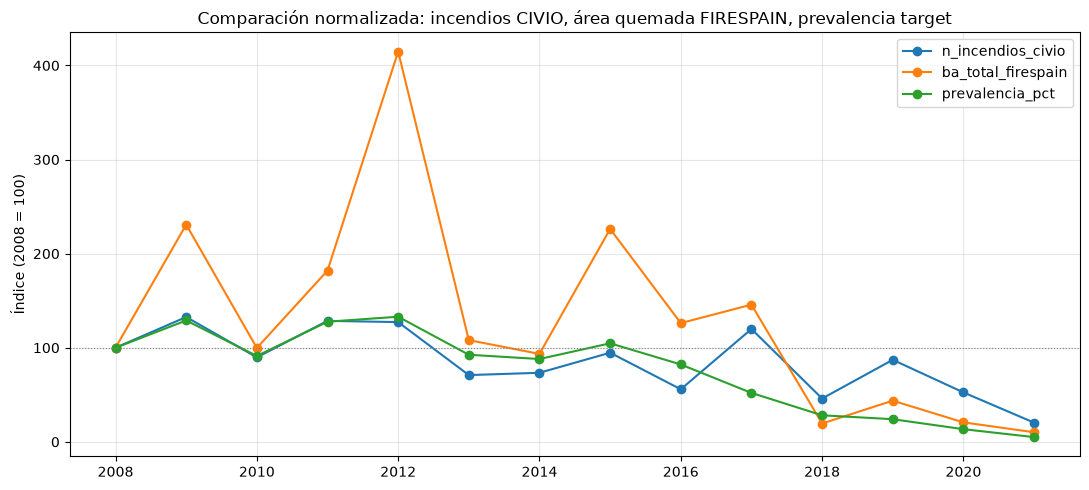

In [12]:
# ============================================================
# COMPARACIÓN CONJUNTA — CIVIO (n_incendios) vs FIRESPAIN (ba_total)
# vs PREVALENCIA DEL TARGET, normalizados para comparar forma
# de la tendencia, no magnitud absoluta.
# Objetivo: distinguir entre (a) fenómeno real coherente entre
# fuentes independientes, (b) sesgo de calidad ya descartado,
# (c) retraso de consolidación administrativa (caída abrupta
# solo en los últimos 1-2 años, no gradual).
# ============================================================

comparacion = pd.DataFrame({
    "n_incendios_civio": n_incendios_anio.loc[2008:2021],
    "ba_total_firespain": ba_anual.loc[2008:2021],
    "prevalencia_pct": prevalencia_anual.loc[2008:2021]
})

# Normalización a índice base 100 en 2008, para comparar FORMA
# de la caída, no magnitud (las tres series tienen escalas muy distintas)
comparacion_norm = comparacion / comparacion.iloc[0] * 100

print("="*60)
print("SERIES NORMALIZADAS (base 100 = año 2008)")
print("="*60)
print(comparacion_norm.round(1))

# Correlación entre las tres series — si están fuertemente
# correlacionadas, apunta a un fenómeno subyacente común (real)
print("\nCorrelación entre series (Pearson):")
print(comparacion.corr().round(3))

# Variación año a año (%) — para detectar si la caída es GRADUAL
# o si hay un ESCALÓN abrupto concentrado en 1-2 años concretos
# (patrón típico de retraso de consolidación administrativa)
variacion_interanual = comparacion.pct_change() * 100
print("\nVariación interanual (%):")
print(variacion_interanual.round(1))

fig, ax = plt.subplots(figsize=(11,5))
for col in comparacion_norm.columns:
    ax.plot(comparacion_norm.index, comparacion_norm[col], marker="o", label=col)
ax.axhline(100, color="gray", linestyle=":", linewidth=0.8)
ax.set_ylabel("Índice (2008 = 100)")
ax.set_title("Comparación normalizada: incendios CIVIO, área quemada FIRESPAIN, prevalencia target")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

399 celda-días con incendio en un solo mes (octubre 2017) es una cifra coherente con el episodio catastróficos Portugal/Galicia, no es una subrepresentación. Así que la divergencia de 2017 no viene de las celdas excluidas del dominio: los grandes incendios de Galicia/Portugal sí están bien capturados en tus 817 celdas.

Asi mismo, dado que durante el diseño del protocolo de validación se observó una disminución progresiva de la prevalencia del target en los últimos años del periodo de estudio, se evaluó si dicha reducción podía deberse a un deterioro en la calidad del registro de incendios.

Para ello se analizaron conjuntamente tres indicadores independientes:

- número anual de incendios registrados en CIVIO,
- superficie quemada anual procedente de FIRESPAIN,
- prevalencia anual del target utilizado para el entrenamiento.

Los resultados muestran una elevada coherencia entre las tres series (r = 0.75–0.80), indicando que todas reflejan una evolución temporal similar.

Además, el porcentaje de registros con coordenadas exactas en CIVIO aumenta desde aproximadamente el 79% en 2008 hasta valores cercanos al 100% a partir de 2012, descartando que la disminución observada pueda atribuirse a un deterioro progresivo de la calidad espacial del registro.

En consecuencia, la reducción de la prevalencia del target parece responder principalmente a una disminución real del número de incendios registrados durante los últimos años del periodo de estudio, si bien no puede descartarse completamente la existencia de efectos asociados a la consolidación administrativa de los datos más recientes.

In [13]:
# ============================================================
# FOLDS WALK-FORWARD — VENTANA RECORTADA
# Se retrasa el inicio de los folds para reducir la disparidad
# de tamaño de train entre el primer y el último fold (antes:
# 6 años vs 13 años, ratio ~2.2x). Ahora el primer fold arranca
# con una base mínima más sustancial.
# ============================================================

folds = []
tabla = []

anio_inicio_val = 2016

for fold, anio_val in enumerate(range(anio_inicio_val, 2021), start=1):
    train_years = list(range(2008, anio_val))
    train = df_modelado[df_modelado.anio.isin(train_years)]
    val   = df_modelado[df_modelado.anio == anio_val]

    folds.append({"fold": fold, "train_years": train_years, "val_year": anio_val})

    tabla.append({
        "Fold": fold,
        "Train": f"{train_years[0]}-{train_years[-1]}",
        "Validación": anio_val,
        "Años train": len(train_years),
        "Filas train": len(train),
        "Filas val": len(val),
        "Prev train (%)": train.target_incendio.mean() * 100,
        "Prev val (%)": val.target_incendio.mean() * 100
    })

tabla_folds = pd.DataFrame(tabla)
print_header("MODELO - WALK-FORWARD (ventana recortada)")
display(tabla_folds.round(3))

ratio_desigualdad = tabla_folds["Años train"].max() / tabla_folds["Años train"].min()
print(f"\nRatio años train (último/primero): {ratio_desigualdad:.2f}x "
      f"(antes del recorte: {13/6:.2f}x)")

MODELO - WALK-FORWARD (ventana recortada)


,Fold,Train,Validación,Años train,Filas train,Filas val,Prev train (%),Prev val (%)
0,1,2008-2015,2016,8,2387274,299022,2.884,2.190
1,2,2008-2016,2017,9,2686296,298205,2.807,1.385
2,3,2008-2017,2018,10,2984501,298205,2.665,0.751
3,4,2008-2018,2019,11,3282706,298205,2.491,0.640
4,5,2008-2019,2020,12,3580911,299022,2.337,0.358



Ratio años train (último/primero): 1.50x (antes del recorte: 2.17x)


Contexto de no-estacionariedad documentado: la prevalencia del target decrece de forma significativa y sostenida (p=0.00003), coherente entre CIVIO, FIRESPAIN y el target binario (r=0.75-0.80). El año de test (2021) corresponde al régimen de menor incidencia de toda la serie histórica — se reporta con ese contexto explícito.

# FEATURE ENGINEERING

In [14]:
# ============================================================
# MODELADO — INGENIERÍA DE VARIABLES
# ============================================================
df = pd.read_parquet(ruta_dataset_maestro)
df["anio"] = df["time"].dt.year
df = df[df["anio"] <= 2021].copy()   # excluye el día suelto de 2022

# Variable temporal continua
df["dias_desde_inicio"] = (df["time"] - df["time"].min()).dt.days.astype(int)

# Estacionalidad cíclica (seno/coseno del día del año)
# Evita la discontinuidad diciembre→enero que tendría "mes" o "día_juliano" crudos
df["dia_juliano"] = df["time"].dt.dayofyear
df["mes_sin"] = np.sin(2 * np.pi * df["dia_juliano"] / 365.25)
df["mes_cos"] = np.cos(2 * np.pi * df["dia_juliano"] / 365.25)

print_header("INGENIERÍA DE VARIABLES — RESUMEN")
print(f"Filas: {len(df):,}")
print(f"dias_desde_inicio: {df['dias_desde_inicio'].min()} hasta {df['dias_desde_inicio'].max()}")

INGENIERÍA DE VARIABLES — RESUMEN
Filas: 4,178,138
dias_desde_inicio: 0 hasta 5113


In [15]:
# ============================================================
# VERIFICACIÓN — extrapolación de dias_desde_inicio en el holdout
# (documentar como limitación conocida, no descubrimiento sorpresa)
# ============================================================
train_final = df[df["anio"] <= 2020]
test_final  = df[df["anio"] == 2021]

max_dias_train = train_final["dias_desde_inicio"].max()
min_dias_test  = test_final["dias_desde_inicio"].min()

print_header("MODELADO - VERIFICACIÓN RANGO DE: dias_desde_inicio")
print(f"Máximo en train (2008-2020): {max_dias_train}")
print(f"Mínimo en test  (2021)     : {min_dias_test}")
print(f"El test está fuera del rango de train: {min_dias_test > max_dias_train}")

MODELADO - VERIFICACIÓN RANGO DE: dias_desde_inicio
Máximo en train (2008-2020): 4748
Mínimo en test  (2021)     : 4749
El test está fuera del rango de train: True


True: los árboles no pueden extrapolar la tendencia en 2021, solo replicar el comportamiento aprendido para finales de 2020. Se documenta como limitación; se conserva la variable como hipótesis a validar empíricamente en el walk-forward

In [16]:
# ============================================================
# ANÁLISIS DE REDUNDANCIA — variables SWI (informativo)
# ============================================================

cols_swi = ["swi_T10_swvl1","swi_T10_swvl2","swi_T20_swvl1","swi_T20_swvl2",
            "swi_T40_swvl1","swi_T40_swvl2"]

print_header("CORRELACIÓN ENTRE VARIABLES SWI")
display(df[cols_swi].corr().round(3))

CORRELACIÓN ENTRE VARIABLES SWI


,swi_T10_swvl1,swi_T10_swvl2,swi_T20_swvl1,swi_T20_swvl2,swi_T40_swvl1,swi_T40_swvl2
swi_T10_swvl1,1.000,0.957,0.985,0.923,0.923,0.844
swi_T10_swvl2,0.957,1.000,0.969,0.987,0.936,0.930
swi_T20_swvl1,0.985,0.969,1.000,0.961,0.973,0.910
swi_T20_swvl2,0.923,0.987,0.961,1.000,0.963,0.974
swi_T40_swvl1,0.923,0.936,0.973,0.963,1.000,0.962
swi_T40_swvl2,0.844,0.930,0.910,0.974,0.962,1.000



Las seis variantes de SWI presentan una elevada correlación entre sí, como era esperable al derivar de la misma señal física mediante diferentes constantes de tiempo.

No se eliminan en esta fase porque:
- Los modelos de árboles son relativamente robustos a la colinealidad.
- El objetivo es evaluar empíricamente su contribución mediante interpretabilidad (SHAP) una vez entrenado el modelo final.


In [17]:
# ============================================================
# DEFINICIÓN DEL CONJUNTO DE FEATURES
# ============================================================

FEATURES_BASE = [
    "swvl1", "swvl2", "t2m", "tp",
    "swi_T10_swvl1", "swi_T10_swvl2", "swi_T20_swvl1", "swi_T20_swvl2",
    "swi_T40_swvl1", "swi_T40_swvl2",
    "elevacion", "pendiente",
    "densidad_igniciones", "pct_causa_antropica", "pct_causa_rayo",
    "dias_desde_inicio", "mes_sin", "mes_cos",
]
FEATURES_CON_LATLON = FEATURES_BASE + ["latitude", "longitude"]
TARGET = "target_incendio"

assert "target_ba" not in FEATURES_BASE, "FUGA: target_ba no debe ser feature"
assert "time" not in FEATURES_BASE, "time no debe ser feature directamente"

print_header("CONJUNTOS DE FEATURES DEFINIDOS")
print(f"FEATURES_BASE       ({len(FEATURES_BASE)}): {FEATURES_BASE}")
print(f"FEATURES_CON_LATLON ({len(FEATURES_CON_LATLON)}): +latitude, +longitude")

assert all(c in df.columns for c in FEATURES_BASE)

CONJUNTOS DE FEATURES DEFINIDOS
FEATURES_BASE       (18): ['swvl1', 'swvl2', 't2m', 'tp', 'swi_T10_swvl1', 'swi_T10_swvl2', 'swi_T20_swvl1', 'swi_T20_swvl2', 'swi_T40_swvl1', 'swi_T40_swvl2', 'elevacion', 'pendiente', 'densidad_igniciones', 'pct_causa_antropica', 'pct_causa_rayo', 'dias_desde_inicio', 'mes_sin', 'mes_cos']
FEATURES_CON_LATLON (20): +latitude, +longitude


In [18]:
# ============================================================
# GENERADOR DE ÍNDICES PARA RandomizedSearchCV
# ============================================================

df_wf = train_final.reset_index(drop=True)
cv_walkforward = construir_cv_walkforward(df_wf, folds)

print_header("GENERADOR CV — VERIFICACIÓN")
for i, (tr_idx, val_idx) in enumerate(cv_walkforward, start=1):
    anios_tr = sorted(df_wf.loc[tr_idx, "anio"].unique())
    anios_val = sorted(df_wf.loc[val_idx, "anio"].unique())
    print(f"Fold {i}: train años {anios_tr[0]}-{anios_tr[-1]} ({len(tr_idx):,} filas) | "
          f"val año {anios_val[0]} ({len(val_idx):,} filas)")

assert 2021 not in df_wf["anio"].unique(), "El holdout 2021 se ha colado en el walk-forward"
for tr_idx, val_idx in cv_walkforward:
    assert len(set(tr_idx) & set(val_idx)) == 0, "Solape entre train y val dentro de un fold"
print("\nVerificado: sin solape train/val por fold, holdout 2021 excluido del walk-forward.")

GENERADOR CV — VERIFICACIÓN
Fold 1: train años 2008-2015 (2,387,274 filas) | val año 2016 (299,022 filas)
Fold 2: train años 2008-2016 (2,686,296 filas) | val año 2017 (298,205 filas)
Fold 3: train años 2008-2017 (2,984,501 filas) | val año 2018 (298,205 filas)
Fold 4: train años 2008-2018 (3,282,706 filas) | val año 2019 (298,205 filas)
Fold 5: train años 2008-2019 (3,580,911 filas) | val año 2020 (299,022 filas)

Verificado: sin solape train/val por fold, holdout 2021 excluido del walk-forward.


# PREPARACIÓN DE MATRICES DE ENTRENAMIENTO

In [19]:
# ============================================================
# VERIFICACIÓN DEL HOLDOUT FINAL
# ============================================================
holdout = obtener_holdout(
    df,
    train_years=list(range(2008, 2021)),
    test_year=2021,
    features=FEATURES_BASE,
    target=TARGET
)

print_header("MODELADO - MATRICES HOLDOUT")
print(f"X_train: {holdout['X_train'].shape}")
print(f"X_test : {holdout['X_test'].shape}")
print(f"\nPrevalencia train: {100*holdout['y_train'].mean():.3f}%")
print(f"Prevalencia test : {100*holdout['y_test'].mean():.3f}%")
print(f"\nclass_weight: {holdout['class_weight']}")
print(f"scale_pos_weight: {holdout['scale_pos_weight']:.2f}")

print("\nVerificado: todas las matrices utilizan el mismo conjunto de variables.")

MODELADO - MATRICES HOLDOUT
X_train: (3879933, 18)
X_test : (298205, 18)

Prevalencia train: 2.184%
Prevalencia test : 0.133%

class_weight: {0: 0.5111653348032664, 1: 22.89073027410353}
scale_pos_weight: 44.78

Verificado: todas las matrices utilizan el mismo conjunto de variables.


Las matrices de entrenamiento y validación se generan mediante funciones auxiliares reutilizables que garantizan que todos los modelos empleen exactamente la misma partición temporal y el mismo cálculo dinámico de pesos de clase.

In [20]:
# ============================================================
# VERIFICACIÓN FOLD WALK-FORWARD
# ============================================================
fold1 = obtener_fold(df_wf, folds[0], FEATURES_BASE, TARGET)
print_header("MODELADO - FOLD 1")
print(f"Train: {fold1['X_train'].shape}")
print(f"Validación: {fold1['X_val'].shape}")
print(f"\nPrevalencia train: {100*fold1['y_train'].mean():.3f}%")
print(f"Prevalencia val  : {100*fold1['y_val'].mean():.3f}%")
print(f"\nscale_pos_weight: {fold1['scale_pos_weight']:.2f}")


fold5 = obtener_fold(df_wf, folds[4], FEATURES_BASE, TARGET)
print()
print_header("MODELADO - FOLD 5")
print(f"Train: {fold5['X_train'].shape}")
print(f"Validación: {fold5['X_val'].shape}")
print(f"\nPrevalencia train: {100*fold5['y_train'].mean():.3f}%")
print(f"Prevalencia val  : {100*fold5['y_val'].mean():.3f}%")
print(f"\nscale_pos_weight: {fold5['scale_pos_weight']:.2f}")

MODELADO - FOLD 1
Train: (2387274, 18)
Validación: (299022, 18)

Prevalencia train: 2.884%
Prevalencia val  : 2.190%

scale_pos_weight: 33.67

MODELADO - FOLD 5
Train: (3580911, 18)
Validación: (299022, 18)

Prevalencia train: 2.337%
Prevalencia val  : 0.358%

scale_pos_weight: 41.79


In [21]:
assert holdout["X_train"].isnull().sum().sum() == 0
assert holdout["X_test"].isnull().sum().sum() == 0
assert holdout["y_train"].isnull().sum() == 0
assert holdout["y_test"].isnull().sum() == 0

print("\nVerificado: sin valores perdidos")


Verificado: sin valores perdidos


# BASELINE

## Regresión Logística

Antes de invertir tiempo en modelos más complejos (Random Forest, XGBoost, LightGBM), se establece una referencia mínima con regresión logística. Cualquier modelo posterior que no supere claramente esta referencia no justificaría su mayor complejidad.

Se entrena con class_weight='balanced' (calculado dinámicamente por conjunto, dada la no estacionariedad de la prevalencia ya documentada) y se evalúa primero en los 5 folds del walk-forward, después en el holdout final de 2021.

In [22]:
# ============================================================
# BASELINE — REGRESIÓN LOGÍSTICA
# Walk-forward (2016-2020)
# ============================================================

PARAMS_LOGISTICA = {"max_iter": 1000, "random_state": 42}
resultados_baseline = []

for i, fold in enumerate(folds, start=1):
    fd = obtener_fold(
        df=df_wf,
        fold=fold,
        features=FEATURES_BASE,
        target=TARGET)

    # Escalado
    scaler = StandardScaler()
    X_train = scaler.fit_transform(fd["X_train"])
    X_val = scaler.transform(fd["X_val"])

    # Modelo
    modelo = LogisticRegression(class_weight=fd["class_weight"], **PARAMS_LOGISTICA)
    modelo.fit(X_train, fd["y_train"])

    # Predicción
    proba = modelo.predict_proba(X_val)[:, 1]
    metricas = evaluar_modelo(fd["y_val"], proba)
    metricas["Fold"] = i
    metricas["Val año"] = fold["val_year"]
    resultados_baseline.append(metricas)

df_baseline = (pd.DataFrame(resultados_baseline).set_index("Fold"))
print_header("BASELINE — REGRESIÓN LOGÍSTICA — WALK-FORWARD")

display(
    df_baseline[
        [
            "Val año",
            "PR-AUC",
            "ROC-AUC",
            "Recall",
            "Precision",
            "F1",
            "Accuracy (informativa)"
        ]
    ].round(4)
    )

print("\nResumen")
print(
    f"PR-AUC : {df_baseline['PR-AUC'].mean():.4f}"
    f" ± {df_baseline['PR-AUC'].std():.4f}")

print(
    f"Recall : {df_baseline['Recall'].mean():.4f}"
    f" ± {df_baseline['Recall'].std():.4f}")

BASELINE — REGRESIÓN LOGÍSTICA — WALK-FORWARD


,Val año,PR-AUC,ROC-AUC,Recall,Precision,F1,Accuracy (informativa)
Fold,,,,,,,
1,2016,0.1125,0.7916,0.7003,0.0529,0.0984,0.7190
2,2017,0.0362,0.7103,0.5539,0.0266,0.0507,0.7128
3,2018,0.0227,0.7568,0.4882,0.0202,0.0387,0.8179
4,2019,0.0202,0.7508,0.4089,0.0193,0.0369,0.8634
5,2020,0.0211,0.8449,0.5257,0.0195,0.0375,0.9034



Resumen
PR-AUC : 0.0425 ± 0.0396
Recall : 0.5354 ± 0.1071


In [23]:
# ============================================================
# BASELINE — HOLDOUT FINAL (2021)
# ============================================================

scaler = StandardScaler()
X_train = scaler.fit_transform(holdout["X_train"])
X_test = scaler.transform(holdout["X_test"])

modelo_baseline = LogisticRegression(class_weight=holdout["class_weight"], **PARAMS_LOGISTICA)
modelo_baseline.fit(X_train, holdout["y_train"])
proba_test = modelo_baseline.predict_proba(X_test)[:, 1]

metricas_holdout = evaluar_modelo(holdout["y_test"], proba_test)

print_header("BASELINE — REGRESIÓN LOGÍSTICA — HOLDOUT")
for nombre, valor in metricas_holdout.items():
    print(f"{nombre:25s}: {valor:.4f}")
print(
    f"\nPrevalencia del holdout (2021): "
    f"{100*holdout['y_test'].mean():.3f}%"
    )

BASELINE — REGRESIÓN LOGÍSTICA — HOLDOUT
PR-AUC                   : 0.0022
ROC-AUC                  : 0.7123
Recall                   : 0.0075
Precision                : 0.0002
F1                       : 0.0004
Accuracy (informativa)   : 0.9460

Prevalencia del holdout (2021): 0.133%


En los 5 folds (2016-2020), a threshold=0.5, el recall se mantiene siempre entre 0.41 y 0.70. Mientras que en el holdout de 2021, con ese mismo threshold, el recall cae a 0.0075, no es una caída proporcional a la menor prevalencia de 2021, sino un colapso de dos órdenes de magnitud

El ROC-AUC, sin embargo, se mantiene en 0.71. Esto significa que si el modelo no distinguiera riesgo relativo, el ROC-AUC también se habría desplomado. Que se mantenga sugiere que el problema no es que el modelo "no sepa nada" de 2021, sino algo más específico

Entonces: ¿es un problema de calibración del umbral de decisión? Con una prevalencia en 2021 dieciséis veces menor que la media de entrenamiento, es plausible que threshold=0.5 ya no sea un punto de corte razonable para este año. Se investiga comparando la distribución de probabilidades predichas en 2021 frente a un año de régimen similar (2020), y examinando la curva Precision-Recall completa del holdout, no solo el punto correspondiente a 0.5

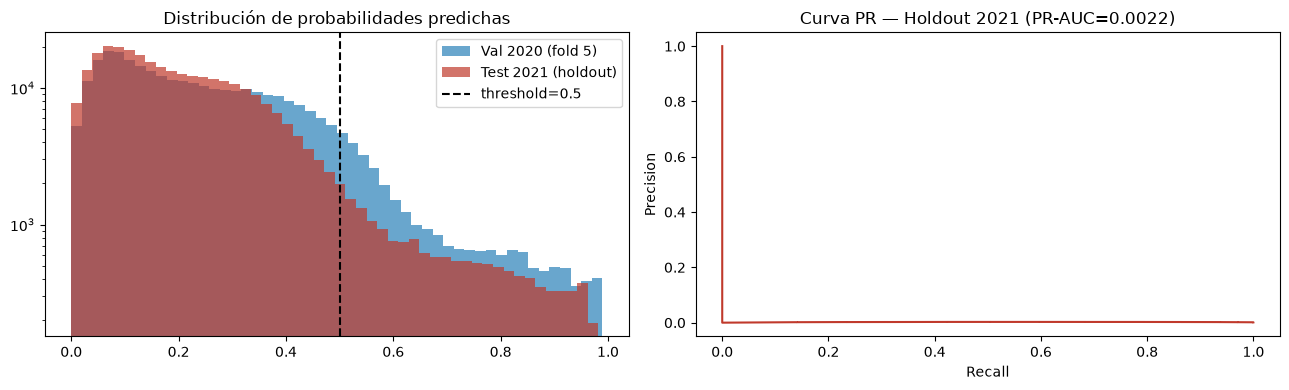

Percentiles de proba_test (2021): p50=0.1818, p90=0.4138, p99=0.8132, max=0.9822

% de observaciones con proba >= 0.5 en test 2021: 5.2725%
% de observaciones con proba >= 0.5 en val 2020   : 9.6765%


In [24]:
# ============================================================
# DIAGNÓSTICO — ¿ES UN PROBLEMA DE CALIBRACIÓN DE UMBRAL,
# O EL MODELO REALMENTE PIERDE CAPACIDAD PREDICTIVA EN 2021?
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Comparar la distribución de probabilidades predichas:
# fold 5 (val=2020, el año más parecido en régimen) vs holdout (test=2021)
fd5 = obtener_fold(df_wf, folds[-1], FEATURES_BASE, target=TARGET)
scaler5 = StandardScaler()
X_train5 = scaler5.fit_transform(fd5["X_train"])
X_val5   = scaler5.transform(fd5["X_val"])
modelo5 = LogisticRegression(class_weight=fd5["class_weight"], **PARAMS_LOGISTICA)
modelo5.fit(X_train5, fd5["y_train"])
proba_2020 = modelo5.predict_proba(X_val5)[:, 1]

axes[0].hist(proba_2020, bins=50, color="#2980b9", alpha=0.7, label="Val 2020 (fold 5)")
axes[0].hist(proba_test, bins=50, color="#c0392b", alpha=0.7, label="Test 2021 (holdout)")
axes[0].axvline(0.5, color="black", linestyle="--", label="threshold=0.5")
axes[0].set_title("Distribución de probabilidades predichas")
axes[0].legend()
axes[0].set_yscale("log")

# Curva Precision-Recall completa del holdout — para ver si hay
# recall razonable a OTRO umbral, no solo en 0.5
from sklearn.metrics import precision_recall_curve
prec, rec, thresholds = precision_recall_curve(holdout["y_test"], proba_test)
axes[1].plot(rec, prec, color="#c0392b")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Curva PR — Holdout 2021 (PR-AUC={metricas_holdout['PR-AUC']:.4f})")

plt.tight_layout()
plt.show()

print(f"Percentiles de proba_test (2021): "
      f"p50={np.percentile(proba_test,50):.4f}, p90={np.percentile(proba_test,90):.4f}, "
      f"p99={np.percentile(proba_test,99):.4f}, max={proba_test.max():.4f}")
print(f"\n% de observaciones con proba >= 0.5 en test 2021: {100*(proba_test>=0.5).mean():.4f}%")
print(f"% de observaciones con proba >= 0.5 en val 2020   : {100*(proba_2020>=0.5).mean():.4f}%")

Como complemento visual, se examina si las probabilidades predichas para los casos positivos reales de 2021 se distinguen de las de los negativos, o si ambas distribuciones son indistinguibles entre sí (lo cual apuntaría a pérdida total de señal, no a un problema de calibración)

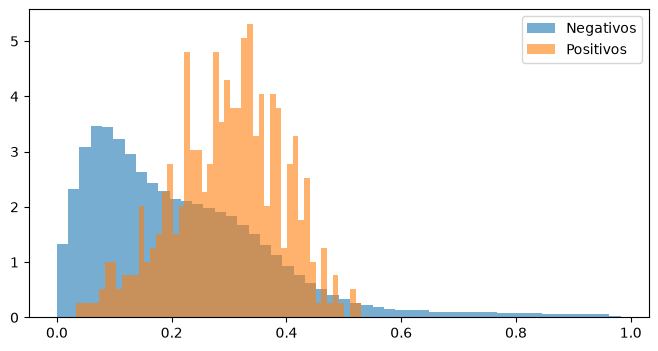

In [25]:
plt.figure(figsize=(8,4))

plt.hist(
    proba_test[holdout["y_test"]==0],
    bins=50,
    density=True,
    alpha=0.6,
    label="Negativos"
)

plt.hist(
    proba_test[holdout["y_test"]==1],
    bins=50,
    density=True,
    alpha=0.6,
    label="Positivos"
)

plt.legend()

**Experimento con fuga de información**: 
El siguiente umbral se optimiza usando directamente las etiquetas reales de 2021 (y_test), lo cual invalida su uso como cifra reportable. Se conserva aquí únicamente como diagnóstico exploratorio, si un umbral elegido con fuga consigue recall razonable, demuestra que el modelo sí contiene señal útil sobre 2021, aunque el umbral honesto (sin mirar el test) todavía esté por determinar

In [26]:
precision, recall, thresholds = precision_recall_curve(holdout["y_test"],proba_test)
f1 = 2*precision*recall/(precision+recall+1e-10)
idx = np.argmax(f1)

print(thresholds[idx])
print(precision[idx])
print(recall[idx])
print(f1[idx])

0.2728171270209457
0.0027555110220440883
0.635678391959799
0.005487236210561776


El umbral con fuga (≈0.27) recupera recall≈0.64 — señal de que el modelo sí contiene información aprovechable sobre 2021. El siguiente paso es cuantificar esa mejora de forma comparable entre años con prevalencias muy distintas, usando el lift (precision ÷ prevalencia) en vez de la precision cruda


In [27]:
# ============================================================
# COMPARACIÓN DE LIFT (precision/prevalencia) — WALK-FORWARD vs HOLDOUT
# Objetivo: Normaliza por prevalencia para comparar años con regímenes
# de riesgo muy distintos de forma justa.
# ============================================================

lift_holdout = precision[idx] / holdout["y_test"].mean()
print(f"Lift holdout (umbral óptimo 0.27): {lift_holdout:.2f}x")

for i, fold in enumerate(folds, start=1):
    fd = obtener_fold(df_wf, fold, FEATURES_BASE, TARGET)
    fila = df_baseline.loc[i]
    lift_fold = fila["Precision"] / fd["y_val"].mean()
    print(f"Fold {i} (val={fold['val_year']}, umbral=0.5): lift = {lift_fold:.2f}x")

Lift holdout (umbral óptimo 0.27): 2.06x
Fold 1 (val=2016, umbral=0.5): lift = 2.42x
Fold 2 (val=2017, umbral=0.5): lift = 1.92x
Fold 3 (val=2018, umbral=0.5): lift = 2.68x
Fold 4 (val=2019, umbral=0.5): lift = 3.02x
Fold 5 (val=2020, umbral=0.5): lift = 5.43x


## Hipótesis A: umbral sin fuga

El experimento anterior no es válido para reportar, pero confirma que vale la pena buscar un umbral elegido correctamente, es decir, usando únicamente los 5 folds del walk-forward, nunca las etiquetas de 2021.

Se calcula el umbral óptimo (máximo F1) en cada fold por separado y se toma la mediana como criterio único, aplicado después al holdout sin volver a mirar y_test en ningún momento del proceso de selección.

In [28]:
# ============================================================
# SELECCIÓN DE UMBRAL — USANDO SOLO EL WALK-FORWARD
# ============================================================

umbrales_optimos_por_fold = []

for i, fold in enumerate(folds, start=1):
    fd = obtener_fold(df_wf, fold, FEATURES_BASE, TARGET)
    scaler_f = StandardScaler()
    X_train_f = scaler_f.fit_transform(fd["X_train"])
    X_val_f   = scaler_f.transform(fd["X_val"])

    modelo_f = LogisticRegression(class_weight=fd["class_weight"], **PARAMS_LOGISTICA)
    modelo_f.fit(X_train_f, fd["y_train"])
    proba_val_f = modelo_f.predict_proba(X_val_f)[:, 1]

    prec_f, rec_f, thr_f = precision_recall_curve(fd["y_val"], proba_val_f)
    f1_f = 2 * prec_f * rec_f / (prec_f + rec_f + 1e-10)
    idx_f = np.argmax(f1_f[:-1])  # el último punto de precision_recall_curve no tiene threshold asociado

    umbrales_optimos_por_fold.append(thr_f[idx_f])
    print(f"Fold {i} (val={fold['val_year']}): umbral óptimo F1 = {thr_f[idx_f]:.4f}")

umbral_final = np.median(umbrales_optimos_por_fold)  # mediana, más robusta que la media ante outliers
print(f"\nUmbral final elegido (mediana de los 5 folds): {umbral_final:.4f}")

# Aplicar ESE umbral, fijo, al holdout — sin volver a mirar y_test para elegirlo
metricas_holdout_calibrado = evaluar_modelo(holdout["y_test"], proba_test, threshold=umbral_final)
print_header("HOLDOUT 2021 — CON UMBRAL SELECCIONADO SIN FUGA")
for k, v in metricas_holdout_calibrado.items():
    print(f"{k:25s}: {v:.4f}")

Fold 1 (val=2016): umbral óptimo F1 = 0.8519
Fold 2 (val=2017): umbral óptimo F1 = 0.7878
Fold 3 (val=2018): umbral óptimo F1 = 0.7893
Fold 4 (val=2019): umbral óptimo F1 = 0.7577
Fold 5 (val=2020): umbral óptimo F1 = 0.6932

Umbral final elegido (mediana de los 5 folds): 0.7878
HOLDOUT 2021 — CON UMBRAL SELECCIONADO SIN FUGA
PR-AUC                   : 0.0022
ROC-AUC                  : 0.7123
Recall                   : 0.0000
Precision                : 0.0000
F1                       : 0.0000
Accuracy (informativa)   : 0.9865


El umbral elegido sin fuga da un resultado muy distinto al umbral con fuga — y, aplicado al holdout, el recall cae a 0. Esto descarta el umbral honesto tal como se calculó, pero abre una segunda hipótesis

## **Hipótesis B: ¿son los umbrales de cada fold comparables entre sí?**

Como class_weight='balanced' se recalcula en cada fold según su propia prevalencia de entrenamiento, cada modelo entrenado podría estar generando probabilidades en una escala distinta, lo que invalidaría promediar (o tomar la mediana de) umbrales absolutos entre folds. Se verifica si scale_pos_weight varía sustancialmente entre folds

In [29]:
for i, fold in enumerate(folds, start=1):
    fd = obtener_fold(df_wf, fold, FEATURES_BASE, TARGET)
    print(f"Fold {i} (val={fold['val_year']}): "
          f"scale_pos_weight={fd['scale_pos_weight']:.2f}, "
          f"class_weight={fd['class_weight']}")

print(f"\nHoldout: scale_pos_weight={holdout['scale_pos_weight']:.2f}")

Fold 1 (val=2016): scale_pos_weight=33.67, class_weight={0: 0.5148482267056299, 1: 17.337027407805486}
Fold 2 (val=2017): scale_pos_weight=34.63, class_weight={0: 0.5144390933694077, 1: 17.81410647497281}
Fold 3 (val=2018): scale_pos_weight=36.53, class_weight={0: 0.5136880743166721, 1: 18.76407383655865}
Fold 4 (val=2019): scale_pos_weight=39.15, class_weight={0: 0.5127725060591614, 1: 20.07329273065258}
Fold 5 (val=2020): scale_pos_weight=41.79, class_weight={0: 0.5119634579680564, 1: 21.396968139773897}

Holdout: scale_pos_weight=44.78


Se observa que scale_pos_weight varía de forma notable entre folds (33.67 a 44.78, ≈33% de variación). Esto motiva normalizar la elección de umbral por percentil dentro de la distribución de probabilidades propia de cada modelo, en vez de comparar valores absolutos entre modelos con escalas de probabilidad distintas.

In [30]:
# ============================================================
# UMBRAL POR PERCENTIL, NO POR VALOR ABSOLUTO
# ============================================================

percentiles_optimos_por_fold = []

for i, fold in enumerate(folds, start=1):
    fd = obtener_fold(df_wf, fold, FEATURES_BASE, TARGET)
    scaler_f = StandardScaler()
    X_train_f = scaler_f.fit_transform(fd["X_train"])
    X_val_f   = scaler_f.transform(fd["X_val"])

    modelo_f = LogisticRegression(class_weight=fd["class_weight"], **PARAMS_LOGISTICA)
    modelo_f.fit(X_train_f, fd["y_train"])
    proba_val_f = modelo_f.predict_proba(X_val_f)[:, 1]

    prec_f, rec_f, thr_f = precision_recall_curve(fd["y_val"], proba_val_f)
    f1_f = 2 * prec_f * rec_f / (prec_f + rec_f + 1e-10)
    idx_f = np.argmax(f1_f[:-1])
    umbral_abs_f = thr_f[idx_f]

    # Percentil de ese umbral DENTRO de la distribución de probabilidades del propio fold
    percentil_f = (proba_val_f < umbral_abs_f).mean() * 100
    percentiles_optimos_por_fold.append(percentil_f)

    print(f"Fold {i} (val={fold['val_year']}): umbral abs={umbral_abs_f:.4f} "
          f"→ percentil {percentil_f:.2f}")

percentil_final = np.median(percentiles_optimos_por_fold)
print(f"\nPercentil final elegido (mediana): {percentil_final:.2f}")

# Traducir ese percentil a un umbral ABSOLUTO específico para el holdout, usando la distribución
# de probabilidades propia de proba_test
umbral_holdout_normalizado = np.percentile(proba_test, percentil_final)
print(f"Umbral absoluto equivalente en el holdout: {umbral_holdout_normalizado:.4f}")

metricas_holdout_normalizado = evaluar_modelo(holdout["y_test"], proba_test, threshold=umbral_holdout_normalizado)
print_header("HOLDOUT 2021 — UMBRAL NORMALIZADO POR PERCENTIL")
for k, v in metricas_holdout_normalizado.items():
    print(f"{k:25s}: {v:.4f}")

Fold 1 (val=2016): umbral abs=0.8519 → percentil 97.41
Fold 2 (val=2017): umbral abs=0.7878 → percentil 96.57
Fold 3 (val=2018): umbral abs=0.7893 → percentil 97.54
Fold 4 (val=2019): umbral abs=0.7577 → percentil 97.58
Fold 5 (val=2020): umbral abs=0.6932 → percentil 97.24

Percentil final elegido (mediana): 97.41
Umbral absoluto equivalente en el holdout: 0.6448
HOLDOUT 2021 — UMBRAL NORMALIZADO POR PERCENTIL
PR-AUC                   : 0.0022
ROC-AUC                  : 0.7123
Recall                   : 0.0000
Precision                : 0.0000
F1                       : 0.0000
Accuracy (informativa)   : 0.9728


Tanto el umbral absoluto (mediana) como el umbral normalizado por percentil producen el mismo resultado: recall ≈ 0 en el holdout. Si la diferencia de class_weight entre folds fuera la causa principal, la normalización por percentiles debería haber recuperado un recall similar al obtenido con fuga (≈0.64). Esto descarta la Hipótesis B como explicación suficiente.

## **Hipótesis C: cambio de distribución (dataset shift) entre entrenamiento y 2021.** 
Se examina directamente dónde caen los positivos reales de 2021 dentro del ranking de probabilidades del modelo (sin depender de ningún umbral) para saber si el modelo al menos concentra algo de señal en la parte alta del ranking.

In [31]:
df_rank = pd.DataFrame({"proba": proba_test, "real": holdout["y_test"]})
df_rank = df_rank.sort_values("proba", ascending=False)

for p in [0.1,0.5,1,2,5]:
    n = int(len(df_rank)*p/100)
    recall = df_rank.head(n)["real"].sum()/df_rank["real"].sum()
    print(p, recall)

0.1 0.0
0.5 0.0
1 0.0
2 0.0
5 0.007537688442211055


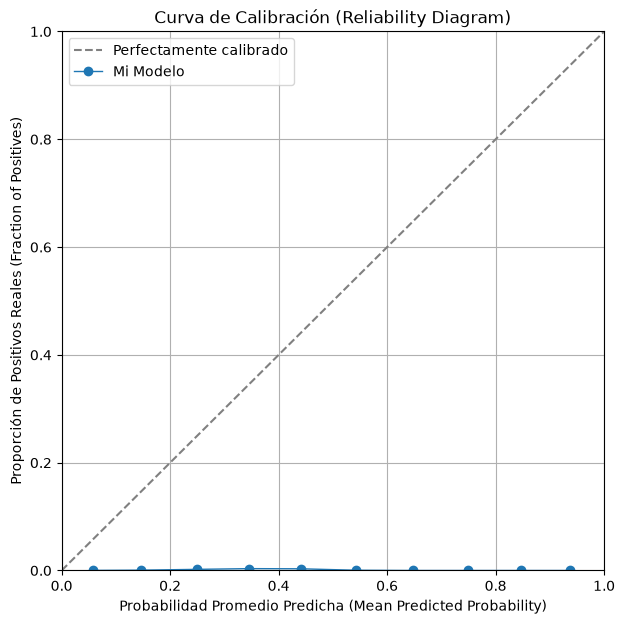

In [32]:
prob_true, prob_pred = calibration_curve(holdout["y_test"], proba_test, n_bins=10)

# Crear la figura y el lienzo
plt.figure(figsize=(7, 7))

# Dibujar la línea de calibración perfecta (referencia)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectamente calibrado")

# Graficar los puntos de tu modelo
plt.plot(prob_pred, prob_true, marker="o", linewidth=1, label="Mi Modelo")

# Configurar etiquetas, títulos y límites
plt.xlabel("Probabilidad Promedio Predicha (Mean Predicted Probability)")
plt.ylabel("Proporción de Positivos Reales (Fraction of Positives)")
plt.title("Curva de Calibración (Reliability Diagram)")
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.grid(True)
plt.legend(loc="upper left")

# Mostrar el gráfico
plt.show()

CONTROL — class_weight=None — HOLDOUT 2021
PR-AUC : 0.0020
ROC-AUC: 0.6877


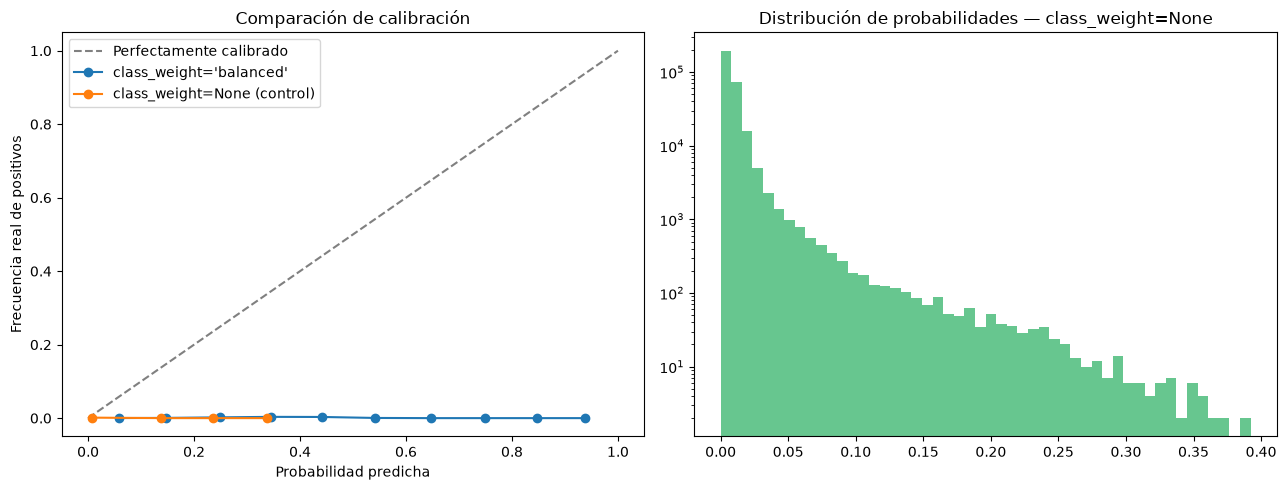

In [33]:
# ============================================================
# EXPERIMENTO DE CONTROL — class_weight=None
# Aísla el efecto de class_weight='balanced' sobre la calibración,
# manteniendo todo lo demás constante (mismas features, mismo split).
# ============================================================

scaler_ctrl = StandardScaler()
X_train_ctrl = scaler_ctrl.fit_transform(holdout["X_train"])
X_test_ctrl  = scaler_ctrl.transform(holdout["X_test"])

modelo_ctrl = LogisticRegression(class_weight=None, max_iter=1000, random_state=42)
modelo_ctrl.fit(X_train_ctrl, holdout["y_train"])
proba_ctrl = modelo_ctrl.predict_proba(X_test_ctrl)[:, 1]

print_header("CONTROL — class_weight=None — HOLDOUT 2021")
print(f"PR-AUC : {average_precision_score(holdout['y_test'], proba_ctrl):.4f}")
print(f"ROC-AUC: {roc_auc_score(holdout['y_test'], proba_ctrl):.4f}")

prob_true_ctrl, prob_pred_ctrl = calibration_curve(holdout["y_test"], proba_ctrl, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].plot([0,1],[0,1], "--", color="gray", label="Perfectamente calibrado")
axes[0].plot(prob_pred, prob_true, marker="o", label="class_weight='balanced'")
axes[0].plot(prob_pred_ctrl, prob_true_ctrl, marker="o", label="class_weight=None (control)")
axes[0].set_xlabel("Probabilidad predicha"); axes[0].set_ylabel("Frecuencia real de positivos")
axes[0].set_title("Comparación de calibración"); axes[0].legend()

axes[1].hist(proba_ctrl, bins=50, color="#27ae60", alpha=0.7)
axes[1].set_title("Distribución de probabilidades — class_weight=None")
axes[1].set_yscale("log")
plt.tight_layout()
plt.show()

El baseline de regresión logística mostró un comportamiento consistente durante la validación walk-forward (2016–2020), manteniendo una capacidad discriminativa moderada (ROC-AUC≈0.71–0.84) y un rendimiento sistemáticamente superior al azar en términos de PR-AUC. Sin embargo, el rendimiento se degradó notablemente en el holdout de 2021, caracterizado por una prevalencia excepcionalmente baja (0.133%). Diversos análisis adicionales descartaron que esta degradación pudiera atribuirse al umbral de decisión o al uso de class_weight='balanced'

Los resultados apuntan a un cambio de distribución entre el periodo de entrenamiento (2008–2020) y el año 2021. Un experimento de control (reentrenamiento con class_weight=None) descartó que class_weight='balanced' fuera el principal responsable: las métricas de discriminación no mejoraron al eliminarlo (ROC-AUC paso de 0.712 a 0.688), lo que indica que la pérdida de rendimiento en 2021 refleja un cambio real en la relación entre predictores y target, no un artefacto de la ponderación de clases

# EVALUACIÓN DE MODELOS

## Random Forest

In [34]:
# ============================================================
# CONFIGURACIÓN COMÚN — RANDOM FOREST
# ============================================================
RANDOM_STATE = 42
SCORING = "average_precision"

# Pesos de clase — calculados UNA vez sobre todo el walk-forward
# (2008-2020), reutilizando la función ya definida en el baseline.
# 2021 queda completamente excluido de este cálculo.
class_weight_wf, scale_pos_weight_wf = calcular_class_weight(df_wf[TARGET])

print_header("CONFIGURACIÓN COMÚN — PESOS DE CLASE")
print(f"Prevalencia positiva (2008-2020): {100*df_wf[TARGET].mean():.4f}%")
print(f"class_weight    : {class_weight_wf}")
print(f"scale_pos_weight: {scale_pos_weight_wf:.2f}")

CONFIGURACIÓN COMÚN — PESOS DE CLASE
Prevalencia positiva (2008-2020): 2.1843%
class_weight    : {0: 0.5111653348032664, 1: 22.89073027410353}
scale_pos_weight: 44.78


In [35]:
# ============================================================
# RANDOM FOREST — ESPACIO DE BÚSQUEDA
# ============================================================
param_distributions_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, 25],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 5, 10],
    "max_features": ["sqrt", "log2", 0.3],
    "bootstrap": [True],
}

rf_base = RandomForestClassifier(
    class_weight=class_weight_wf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print_header("RANDOM FOREST — ESPACIO DE BÚSQUEDA")
for k, v in param_distributions_rf.items():
    print(f"{k:20s}: {v}")

RANDOM FOREST — ESPACIO DE BÚSQUEDA
n_estimators        : [100, 200, 300]
max_depth           : [10, 15, 20, 25]
min_samples_split   : [5, 10, 20]
min_samples_leaf    : [2, 5, 10]
max_features        : ['sqrt', 'log2', 0.3]
bootstrap           : [True]


In [36]:
# ============================================================
# SUBMUESTRA ESTRATIFICADA POR AÑO + TARGET
# Solo para la fase de BÚSQUEDA de hiperparámetros — economiza
# cómputo. El modelo final siempre se reentrena sobre el 100%
# de los datos (ver bloque de refit más abajo).
# Mantiene: estructura temporal, prevalencia aproximada por año,
# proporción de positivos/negativos. 2021 no participa (df_wf
# ya lo excluye).
# ============================================================
frac_muestra = 0.30

df_wf_muestra = (
    df_wf
    .groupby(["anio", TARGET], group_keys=False)
    .sample(frac=frac_muestra, random_state=RANDOM_STATE)
    .reset_index(drop=True)
    )

print_header("SUBMUESTRA — RANDOM FOREST EXPLORATORIO")
print(f"Filas originales : {len(df_wf):,}")
print(f"Filas muestra    : {len(df_wf_muestra):,}")
print(f"\nPrevalencia original: {100*df_wf[TARGET].mean():.4f}%")
print(f"Prevalencia muestra : {100*df_wf_muestra[TARGET].mean():.4f}%")

prev_original = df_wf.groupby("anio")[TARGET].mean().mul(100)
prev_muestra  = df_wf_muestra.groupby("anio")[TARGET].mean().mul(100)

df_prev_comparacion = pd.DataFrame({"Original (%)": prev_original, "Muestra (%)": prev_muestra})
df_prev_comparacion["Diferencia (pp)"] = (df_prev_comparacion["Muestra (%)"] - df_prev_comparacion["Original (%)"])
display(df_prev_comparacion.round(4))

SUBMUESTRA — RANDOM FOREST EXPLORATORIO
Filas originales : 3,879,933
Filas muestra    : 1,163,978

Prevalencia original: 2.1843%
Prevalencia muestra : 2.1842%


,Original (%),Muestra (%),Diferencia (pp)
anio,,,
2008,2.6637,2.6642,0.0005
2009,3.4356,3.4361,0.0005
2010,2.4305,2.4301,-0.0004
2011,3.4007,3.4004,-0.0003
2012,3.5415,3.5415,-0.0000
2013,2.4651,2.4648,-0.0003
2014,2.3444,2.3440,-0.0003
2015,2.7894,2.7889,-0.0004
2016,2.1901,2.1905,0.0003


In [37]:
# ============================================================
# WALK-FORWARD SOBRE LA SUBMUESTRA — PARA LA BÚSQUEDA
# ============================================================
cv_walkforward_muestra = construir_cv_walkforward(df_wf_muestra, folds)
print_header("CV WALK-FORWARD — SUBMUESTRA")
for i, (train_idx, val_idx) in enumerate(cv_walkforward_muestra, start=1):
    print(f"Fold {i}: train={len(train_idx):,} | val={len(val_idx):,}")

X_wf_muestra = df_wf_muestra[FEATURES_BASE]
y_wf_muestra = df_wf_muestra[TARGET]

CV WALK-FORWARD — SUBMUESTRA
Fold 1: train=716,181 | val=89,707
Fold 2: train=805,888 | val=89,462
Fold 3: train=895,350 | val=89,461
Fold 4: train=984,811 | val=89,461
Fold 5: train=1,074,272 | val=89,706


In [38]:
# ============================================================
# RANDOMIZED SEARCH — EXPLORATORIO (sobre la submuestra)
# ============================================================
PARAMS_RANDOM_SEARCH_RF = {
    "n_iter": 15,
    "scoring": SCORING,
    "cv": cv_walkforward_muestra,
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
    "verbose": 2,
    "refit": True,
}

search_rf_exploratorio = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions_rf,
    **PARAMS_RANDOM_SEARCH_RF
)

print_header("RANDOM FOREST — RANDOMIZED SEARCH EXPLORATORIO")
search_rf_exploratorio.fit(X_wf_muestra, y_wf_muestra)

print_header("RANDOM FOREST — MEJOR CONFIGURACIÓN EXPLORATORIA")
print(f"Mejor {SCORING} (sobre submuestra): {search_rf_exploratorio.best_score_:.4f}")
print("\nMejores hiperparámetros:")
for k, v in search_rf_exploratorio.best_params_.items():
    print(f"  {k:20s}: {v}")

RANDOM FOREST — RANDOMIZED SEARCH EXPLORATORIO
Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time=  36.2s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time=  43.8s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time=  47.4s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time=  56.6s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=10, min_samples_split=20, n_estimators=100; total time= 1.0min
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time=  36.3s
[CV] END bootstrap=True, max_depth=15, max_features=log2, min_samp

In [39]:
# ============================================================
# REFIT FINAL — HIPERPARÁMETROS GANADORES, DATASET COMPLETO
# La búsqueda exploratoria solo sirvió para localizar una buena
# región de hiperparámetros
# El modelo que se usa de aquí en adelante (walk-forward completo,
# selección de umbral, holdout) se entrena SIEMPRE sobre el 100%
# de los datos disponibles — nunca sobre la submuestra.
# ============================================================
mejores_params_rf = search_rf_exploratorio.best_params_
X_wf = df_wf[FEATURES_BASE]
y_wf = df_wf[TARGET]

modelo_rf_final = RandomForestClassifier(
    **mejores_params_rf,
    class_weight=class_weight_wf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
modelo_rf_final.fit(X_wf, y_wf)

print_header("RANDOM FOREST — REFIT SOBRE DATASET COMPLETO")
print(f"Entrenado con {len(X_wf):,} filas (100% de 2008-2020)")
print(f"Hiperparámetros: {mejores_params_rf}")

RANDOM FOREST — REFIT SOBRE DATASET COMPLETO
Entrenado con 3,879,933 filas (100% de 2008-2020)
Hiperparámetros: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 25, 'bootstrap': True}


**Nota metodológica sobre la búsqueda de hiperparámetros**: por razones de coste computacional, RandomizedSearchCV se ejecuta con un único class_weight/scale_pos_weight calculado sobre la totalidad de 2008-2020, en lugar de recalcularlo dentro de cada partición del walk-forward. Esto introduce una fuga leve de información agregada de prevalencia (no de etiquetas individuales) hacia los folds de validación durante la fase de selección de hiperparámetros. Las métricas walk-forward reportadas en las tablas siguientes (obtenidas reentrenando con los hiperparámetros ya seleccionados, pero con el peso de clase correcto por fold) no se ven afectadas por esta limitación. El experimento de control del baseline (sección anterior) sugiere que el efecto del class_weight sobre la capacidad discriminativa del modelo es, en cualquier caso, moderado.

In [40]:
# ============================================================
# WALK-FORWARD FUSIONADO — MÉTRICAS + UMBRAL
# ============================================================
resultados_rf_wf = []
umbrales_rf = []

for i, fold in enumerate(folds, start=1):
    fd = obtener_fold(df_wf, fold, FEATURES_BASE, TARGET)
    modelo_fold = RandomForestClassifier(
        **mejores_params_rf,
        class_weight=fd["class_weight"],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    
    modelo_fold.fit(fd["X_train"], fd["y_train"])
    proba_val = modelo_fold.predict_proba(fd["X_val"])[:, 1]

    # Métricas del fold (a threshold=0.5, para la tabla comparativa)
    metricas = evaluar_modelo(fd["y_val"], proba_val)
    metricas["Fold"] = i
    metricas["Val año"] = fold["val_year"]
    resultados_rf_wf.append(metricas)

    # Umbral óptimo del fold (a partir de las MISMAS proba_val)
    umbral_f = obtener_umbral_optimo(fd["y_val"], proba_val)
    umbrales_rf.append(umbral_f)

    print(f"Fold {i} (val={fold['val_year']}): "
          f"PR-AUC={metricas['PR-AUC']:.4f} | umbral óptimo={umbral_f:.4f}")

print_header("RANDOM FOREST — WALK-FORWARD (mejores hiperparámetros)")
df_rf_wf = resumir_resultados(resultados_rf_wf)

umbral_rf_final = np.median(umbrales_rf)
print(f"\nUmbral final Random Forest (mediana de los 5 folds): {umbral_rf_final:.4f}")

Fold 1 (val=2016): PR-AUC=0.1732 | umbral óptimo=0.6095
Fold 2 (val=2017): PR-AUC=0.0527 | umbral óptimo=0.6132
Fold 3 (val=2018): PR-AUC=0.0840 | umbral óptimo=0.5426
Fold 4 (val=2019): PR-AUC=0.1102 | umbral óptimo=0.5782
Fold 5 (val=2020): PR-AUC=0.1549 | umbral óptimo=0.4931
RANDOM FOREST — WALK-FORWARD (mejores hiperparámetros)
   PR-AUC  ROC-AUC  Recall  Precision      F1  Accuracy (informativa)  Fold  \
0  0.1732   0.8302  0.3703     0.1711  0.2340                  0.9469     1   
1  0.0527   0.7668  0.3185     0.0694  0.1140                  0.9315     2   
2  0.0840   0.8338  0.1999     0.1261  0.1547                  0.9836     3   
3  0.1102   0.8546  0.2654     0.1664  0.2046                  0.9868     4   
4  0.1549   0.9446  0.3641     0.2002  0.2584                  0.9925     5   

   Val año  
0     2016  
1     2017  
2     2018  
3     2019  
4     2020  

Resumen
PR-AUC    : 0.1150 ± 0.0496
ROC-AUC   : 0.8460 ± 0.0642
Recall    : 0.3037 ± 0.0717
Precision : 0.1467 

In [41]:
# ============================================================
# HOLDOUT FINAL (2021) — modelo_rf_final (refit sobre 100%)
# ============================================================
proba_test_rf = modelo_rf_final.predict_proba(holdout["X_test"])[:, 1]
metricas_rf_holdout = evaluar_modelo(holdout["y_test"], proba_test_rf, threshold=umbral_rf_final)

print_header("RANDOM FOREST — HOLDOUT 2021 (umbral sin fuga)")
for k, v in metricas_rf_holdout.items():
    print(f"{k:25s}: {v:.4f}")

print(f"\nComparación con baseline (regresión logística) en el mismo holdout:")
print(f"  PR-AUC  RF: {metricas_rf_holdout['PR-AUC']:.4f}  vs  Logística: {metricas_holdout['PR-AUC']:.4f}")
print(f"  ROC-AUC RF: {metricas_rf_holdout['ROC-AUC']:.4f}  vs  Logística: {metricas_holdout['ROC-AUC']:.4f}")

RANDOM FOREST — HOLDOUT 2021 (umbral sin fuga)
PR-AUC                   : 0.0218
ROC-AUC                  : 0.9135
Recall                   : 0.1558
Precision                : 0.0363
F1                       : 0.0589
Accuracy (informativa)   : 0.9934

Comparación con baseline (regresión logística) en el mismo holdout:
  PR-AUC  RF: 0.0218  vs  Logística: 0.0022
  ROC-AUC RF: 0.9135  vs  Logística: 0.7123


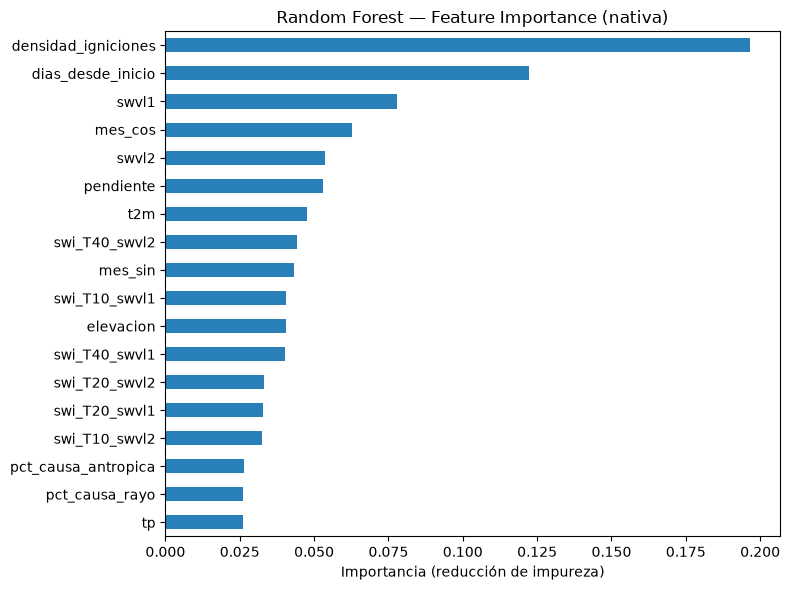

RANDOM FOREST — TOP 5 VARIABLES
densidad_igniciones    0.196701
dias_desde_inicio      0.122413
swvl1                  0.077719
mes_cos                0.062840
swvl2                  0.053584
dtype: float64


In [42]:
# ============================================================
# FEATURE IMPORTANCE NATIVA
# ============================================================
importancias_rf = pd.Series(modelo_rf_final.feature_importances_, index=FEATURES_BASE).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importancias_rf.plot(kind="barh", ax=ax, color="#2980b9")
ax.invert_yaxis()
ax.set_title("Random Forest — Feature Importance (nativa)")
ax.set_xlabel("Importancia (reducción de impureza)")
plt.tight_layout()
plt.show()

print_header("RANDOM FOREST — TOP 5 VARIABLES")
print(importancias_rf.head(5))

In [43]:
# ============================================================
# VERIFICACIÓN DE FUGA — densidad_igniciones
# ============================================================
#CONSTANCIA TEMPORAL POR CELDA
variacion_por_celda = (df_wf.groupby(["latitude", "longitude"])["densidad_igniciones"].nunique())
n_celdas_variantes = (variacion_por_celda > 1).sum()
n_celdas = len(variacion_por_celda)

print_header("VERIFICACIÓN — CONSTANCIA TEMPORAL DE densidad_igniciones")
print(f"Celdas con más de un valor distinto: " f"{n_celdas_variantes:,} de {n_celdas:,}")
assert n_celdas_variantes == 0, (
    "densidad_igniciones varía temporalmente dentro de alguna celda. "
    "Revisar 02_preprocessing.")
print("Constancia temporal verificada.")

# COMPROBACIÓN DE VALORES NULOS
nulos_densidad = df_wf["densidad_igniciones"].isna().sum()
print()
print_header("VERIFICACIÓN — VALORES PERDIDOS")
print(f"Valores nulos en densidad_igniciones: {nulos_densidad:,}")
assert nulos_densidad == 0, ("Existen valores nulos en densidad_igniciones.")
print("Sin valores nulos.")

# COMPROBACIÓN DESCRIPTIVA DE ASOCIACIÓN CON EL TARGET
corr_por_anio = (df_wf.groupby("anio").apply(lambda g: g["densidad_igniciones"].corr(g[TARGET])))
print()
print_header("ANÁLISIS DESCRIPTIVO — CORRELACIÓN")
print(corr_por_anio.round(4))

VERIFICACIÓN — CONSTANCIA TEMPORAL DE densidad_igniciones
Celdas con más de un valor distinto: 0 de 817
Constancia temporal verificada.

VERIFICACIÓN — VALORES PERDIDOS
Valores nulos en densidad_igniciones: 0
Sin valores nulos.

ANÁLISIS DESCRIPTIVO — CORRELACIÓN
anio
2008    0.1629
2009    0.1929
2010    0.1972
2011    0.2373
2012    0.1778
2013    0.1740
2014    0.1049
2015    0.1618
2016    0.1308
2017    0.0787
2018    0.0499
2019    0.0601
2020    0.0868
dtype: float64


In [44]:
# ============================================================
# RANDOM FOREST — RECALL@TOP-K%
# ============================================================
print_header("RANDOM FOREST — RECALL TOP-K% (HOLDOUT 2021)")
for p in [0.1, 0.5, 1, 2, 5]:
    ic = recall_en_top_k_bootstrap(
        proba_test_rf,
        holdout["y_test"].values,
        p,
        n_bootstrap=1000,
        random_state=RANDOM_STATE
    )
    print(f"Top {p}%:   recall mediana = {ic[1]:.4f}    IC95%=[{ic[0]:.4f}, {ic[2]:.4f}]")

RANDOM FOREST — RECALL TOP-K% (HOLDOUT 2021)
Top 0.1%:   recall mediana = 0.0079    IC95%=[0.0000, 0.0185]
Top 0.5%:   recall mediana = 0.1454    IC95%=[0.1108, 0.1801]
Top 1%:   recall mediana = 0.2385    IC95%=[0.1974, 0.2790]
Top 2%:   recall mediana = 0.4207    IC95%=[0.3716, 0.4673]
Top 5%:   recall mediana = 0.6830    IC95%=[0.6381, 0.7275]


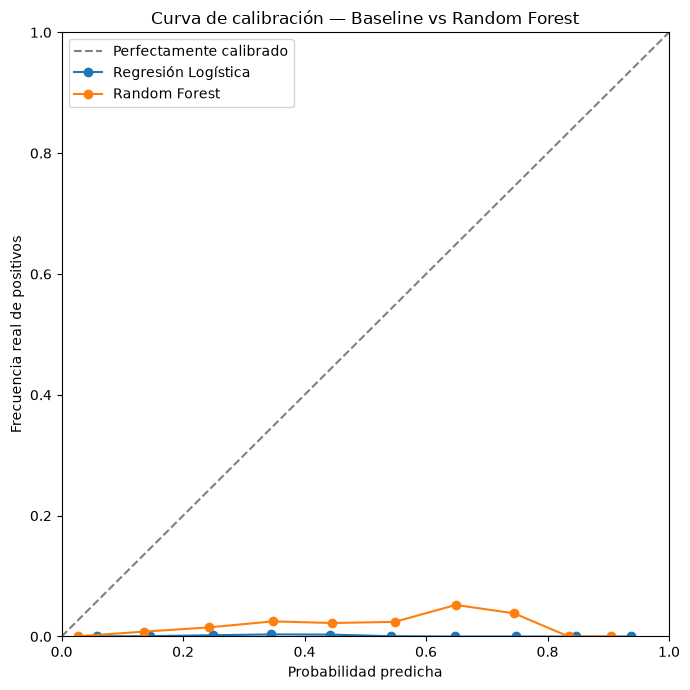

In [45]:
# ============================================================
# RANDOM FOREST — CURVA DE CALIBRACIÓN (HOLDOUT 2021)
# ============================================================
prob_true_rf, prob_pred_rf = calibration_curve(holdout["y_test"], proba_test_rf, n_bins=10)

fig, ax = plt.subplots(figsize=(7,7))
ax.plot([0,1],[0,1], "--", color="gray", label="Perfectamente calibrado")
ax.plot(prob_pred, prob_true, marker="o", label="Regresión Logística")
ax.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Frecuencia real de positivos")
ax.set_title("Curva de calibración — Baseline vs Random Forest")
ax.legend()
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

## XGBoost

In [46]:
# ============================================================
# DETECCIÓN DE GPU DISPONIBLE PARA XGBoost
# ============================================================
def detectar_dispositivo_xgb():
    try:
        modelo_test = xgb.XGBClassifier(tree_method="hist", device="cuda", n_estimators=2)
        modelo_test.fit(X_wf.iloc[:1000], y_wf.iloc[:1000])
        print("GPU disponible — se usará device='cuda'")
        return "cuda"
    except Exception as e:
        print(f"GPU no disponible ({type(e).__name__}) — se usará CPU")
        return "cpu"

DEVICE_XGB = detectar_dispositivo_xgb()

GPU disponible — se usará device='cuda'


In [47]:
# ============================================================
# XGBOOST — ESPACIO DE BÚSQUEDA
# scale_pos_weight (float) en vez de class_weight (dict) — ya
# calculado en el bloque de configuración común (scale_pos_weight_wf).
# device="cuda" ya confirmado disponible en el entorno.
# ============================================================
param_distributions_xgb = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 5, 10],
    "gamma": [0, 0.1, 0.5],
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight_wf,
    tree_method="hist",
    device="cuda",
    random_state=RANDOM_STATE,
    eval_metric="aucpr",
    n_jobs=-1,
)

print_header("XGBOOST — ESPACIO DE BÚSQUEDA")
for k, v in param_distributions_xgb.items():
    print(f"{k:20s}: {v}")

XGBOOST — ESPACIO DE BÚSQUEDA
n_estimators        : [200, 300, 500]
max_depth           : [4, 6, 8, 10]
learning_rate       : [0.01, 0.05, 0.1, 0.2]
subsample           : [0.6, 0.8, 1.0]
colsample_bytree    : [0.6, 0.8, 1.0]
min_child_weight    : [1, 5, 10]
gamma               : [0, 0.1, 0.5]


In [48]:
# ============================================================
# XGBOOST — RandomizedSearchCV SOBRE LA SUBMUESTRA
# Reutiliza df_wf_muestra / cv_walkforward_muestra ya construidos
# para RF — mismo subconjunto, misma partición, comparabilidad
# directa entre modelos.
# ============================================================
PARAMS_RANDOM_SEARCH_XGB = {
    "n_iter": 20,
    "scoring": SCORING,
    "cv": cv_walkforward_muestra,
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
    "verbose": 2,
    "refit": True,
}

search_xgb_exploratorio = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_distributions_xgb,
    **PARAMS_RANDOM_SEARCH_XGB
)

print_header("XGBOOST — RANDOMIZED SEARCH EXPLORATORIO (GPU)")
search_xgb_exploratorio.fit(X_wf_muestra, y_wf_muestra)

print_header("XGBOOST — MEJOR CONFIGURACIÓN EXPLORATORIA")
print(f"Mejor {SCORING} (sobre submuestra): {search_xgb_exploratorio.best_score_:.4f}")
print("\nMejores hiperparámetros:")
for k, v in search_xgb_exploratorio.best_params_.items():
    print(f"  {k:20s}: {v}")

XGBOOST — RANDOMIZED SEARCH EXPLORATORIO (GPU)
Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\Gambo\Documents\Master Aaron\TFM UCM\venv\Lib\site-packages\xgboost\core.py:569: UserWarning: [16:18:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=500, subsample=0.6; total time=  16.2s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=500, subsample=0.6; total time=  18.9s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=500, subsample=0.6; total time=  19.2s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=500, subsample=0.6; total time=  20.7s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=6, min_child_weight=5, n_estimators=500, subsample=0.6; total time=  22.6s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.01, max_depth=6, min_child_weight=10, n_estimators=500, subsample=0.6; total time=  18.2s
[CV] END colsample_bytree=1.0, gamma=0.5, learning_rate=0.01, max_depth=6, min_child_weight=10, n_estimators=500, sub

In [49]:
# ============================================================
# REFIT FINAL — HIPERPARÁMETROS GANADORES DATASET COMPLETO
# ============================================================
mejores_params_xgb = search_xgb_exploratorio.best_params_

modelo_xgb_final = xgb.XGBClassifier(
    **mejores_params_xgb,
    scale_pos_weight=scale_pos_weight_wf,
    tree_method="hist",
    device="cuda",
    random_state=RANDOM_STATE,
    eval_metric="aucpr",
)
modelo_xgb_final.fit(X_wf, y_wf)

print_header("XGBOOST — REFIT SOBRE DATASET COMPLETO")
print(f"Entrenado con {len(X_wf):,} filas (100% de 2008-2020)")
print(f"Hiperparámetros: {mejores_params_xgb}")

XGBOOST — REFIT SOBRE DATASET COMPLETO
Entrenado con 3,879,933 filas (100% de 2008-2020)
Hiperparámetros: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 1.0}


In [50]:
# ============================================================
# WALK-FORWARD FUSIONADO — MÉTRICAS + UMBRAL
# ============================================================
resultados_xgb_wf = []
umbrales_xgb = []

for i, fold in enumerate(folds, start=1):
    fd = obtener_fold(df_wf, fold, FEATURES_BASE, TARGET)

    modelo_fold = xgb.XGBClassifier(
        **mejores_params_xgb,
        scale_pos_weight=fd["scale_pos_weight"],
        tree_method="hist",
        device="cuda",
        random_state=RANDOM_STATE,
        eval_metric="aucpr",
    )
    modelo_fold.fit(fd["X_train"], fd["y_train"])
    proba_val = modelo_fold.predict_proba(fd["X_val"])[:, 1]

    metricas = evaluar_modelo(fd["y_val"], proba_val)
    metricas["Fold"] = i
    metricas["Val año"] = fold["val_year"]
    resultados_xgb_wf.append(metricas)

    umbral_f = obtener_umbral_optimo(fd["y_val"], proba_val)
    umbrales_xgb.append(umbral_f)

    print(f"Fold {i} (val={fold['val_year']}): "
          f"PR-AUC={metricas['PR-AUC']:.4f} | umbral óptimo={umbral_f:.4f}")

print_header("XGBOOST — WALK-FORWARD (mejores hiperparámetros)")
df_xgb_wf = resumir_resultados(resultados_xgb_wf)

umbral_xgb_final = np.median(umbrales_xgb)
print(f"\nUmbral final XGBoost (mediana de los 5 folds): {umbral_xgb_final:.4f}")

Fold 1 (val=2016): PR-AUC=0.1676 | umbral óptimo=0.8213
Fold 2 (val=2017): PR-AUC=0.0547 | umbral óptimo=0.8193
Fold 3 (val=2018): PR-AUC=0.0800 | umbral óptimo=0.6973
Fold 4 (val=2019): PR-AUC=0.1472 | umbral óptimo=0.7326
Fold 5 (val=2020): PR-AUC=0.1906 | umbral óptimo=0.7043
XGBOOST — WALK-FORWARD (mejores hiperparámetros)
   PR-AUC  ROC-AUC  Recall  Precision      F1  Accuracy (informativa)  Fold  \
0  0.1676   0.8263  0.6893     0.0687  0.1250                  0.7886     1   
1  0.0547   0.7616  0.6372     0.0328  0.0623                  0.7345     2   
2  0.0800   0.8167  0.3463     0.0598  0.1019                  0.9541     3   
3  0.1472   0.8357  0.4016     0.0744  0.1256                  0.9642     4   
4  0.1906   0.9386  0.6106     0.1336  0.2192                  0.9844     5   

   Val año  
0     2016  
1     2017  
2     2018  
3     2019  
4     2020  

Resumen
PR-AUC    : 0.1280 ± 0.0582
ROC-AUC   : 0.8358 ± 0.0643
Recall    : 0.5370 ± 0.1528
Precision : 0.0739 ± 0.03

In [51]:
# ============================================================
# HOLDOUT FINAL (2021)
# ============================================================
proba_test_xgb = modelo_xgb_final.predict_proba(holdout["X_test"])[:, 1]
metricas_xgb_holdout = evaluar_modelo(holdout["y_test"], proba_test_xgb, threshold=umbral_xgb_final)

print_header("XGBOOST — HOLDOUT 2021 (umbral sin fuga)")
for k, v in metricas_xgb_holdout.items():
    print(f"{k:25s}: {v:.4f}")

print(f"\nComparación con modelos anteriores en el mismo holdout:")
print(f"  PR-AUC  — Logística: {metricas_holdout['PR-AUC']:.4f} | RF: {metricas_rf_holdout['PR-AUC']:.4f} | XGB: {metricas_xgb_holdout['PR-AUC']:.4f}")
print(f"  ROC-AUC — Logística: {metricas_holdout['ROC-AUC']:.4f} | RF: {metricas_rf_holdout['ROC-AUC']:.4f} | XGB: {metricas_xgb_holdout['ROC-AUC']:.4f}")

XGBOOST — HOLDOUT 2021 (umbral sin fuga)
PR-AUC                   : 0.0116
ROC-AUC                  : 0.8944
Recall                   : 0.0352
Precision                : 0.0058
F1                       : 0.0099
Accuracy (informativa)   : 0.9906

Comparación con modelos anteriores en el mismo holdout:
  PR-AUC  — Logística: 0.0022 | RF: 0.0218 | XGB: 0.0116
  ROC-AUC — Logística: 0.7123 | RF: 0.9135 | XGB: 0.8944


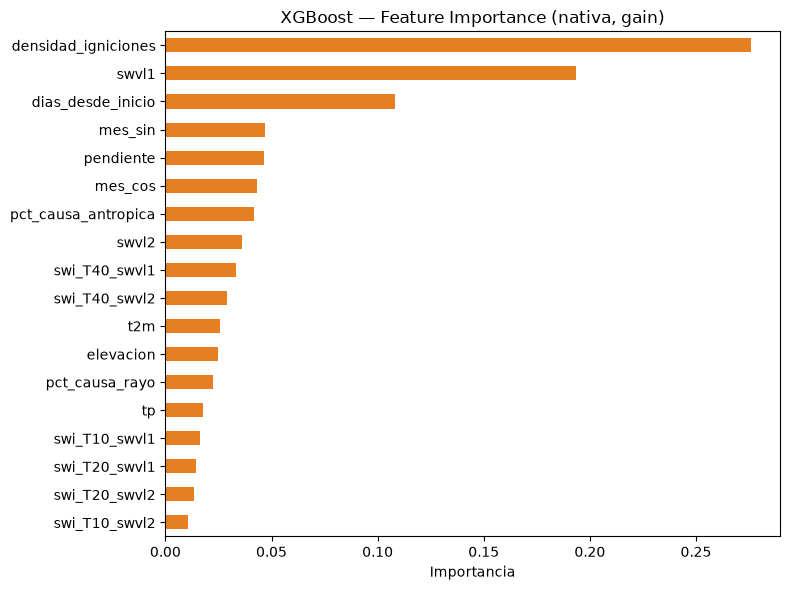

XGBOOST — TOP 5 VARIABLES
densidad_igniciones    0.275802
swvl1                  0.193494
dias_desde_inicio      0.108219
mes_sin                0.046777
pendiente              0.046675
dtype: float32


In [52]:
# ============================================================
# FEATURE IMPORTANCE NATIVA (chequeo de cordura)
# ============================================================
importancias_xgb = pd.Series(
    modelo_xgb_final.feature_importances_, index=FEATURES_BASE).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importancias_xgb.plot(kind="barh", ax=ax, color="#e67e22")
ax.invert_yaxis()
ax.set_title("XGBoost — Feature Importance (nativa, gain)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

print_header("XGBOOST — TOP 5 VARIABLES")
print(importancias_xgb.head(5))

XGBOOST — RECALL TOP-K% (HOLDOUT 2021)
Top 0.1%: recall mediana=0.0000  IC95%=[0.0000, 0.0000]
Top 0.5%: recall mediana=0.0000  IC95%=[0.0000, 0.0000]
Top 1%: recall mediana=0.0763  IC95%=[0.0499, 0.1086]
Top 2%: recall mediana=0.2384  IC95%=[0.1976, 0.2832]
Top 5%: recall mediana=0.5479  IC95%=[0.4987, 0.5982]


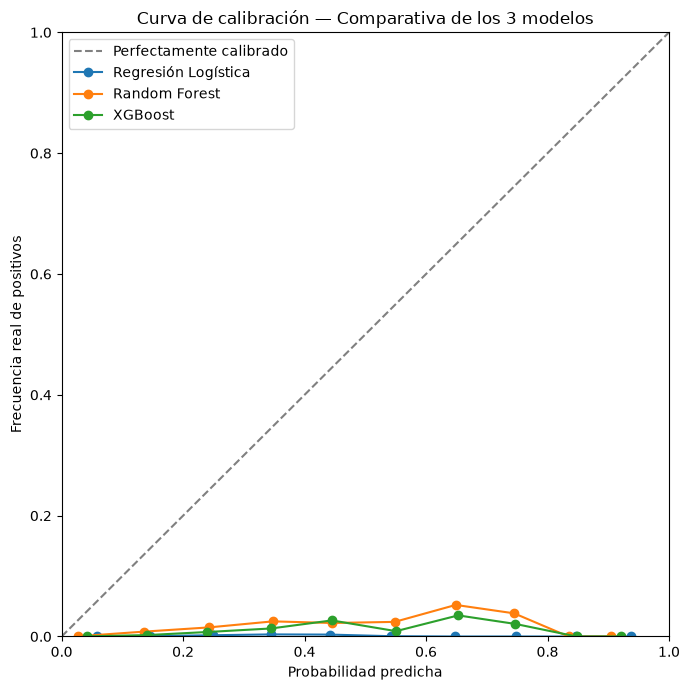

In [53]:
# ============================================================
# DIAGNÓSTICOS — RECALL@TOP-K%
# ============================================================
print_header("XGBOOST — RECALL TOP-K% (HOLDOUT 2021)")
for p in [0.1, 0.5, 1, 2, 5]:
    ic = recall_en_top_k_bootstrap(proba_test_xgb, holdout["y_test"].values, p)
    print(f"Top {p}%: recall mediana={ic[1]:.4f}  IC95%=[{ic[0]:.4f}, {ic[2]:.4f}]")

prob_true_xgb, prob_pred_xgb = calibration_curve(holdout["y_test"], proba_test_xgb, n_bins=10)

fig, ax = plt.subplots(figsize=(7,7))
ax.plot([0,1],[0,1], "--", color="gray", label="Perfectamente calibrado")
ax.plot(prob_pred, prob_true, marker="o", label="Regresión Logística")
ax.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")
ax.plot(prob_pred_xgb, prob_true_xgb, marker="o", label="XGBoost")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Frecuencia real de positivos")
ax.set_title("Curva de calibración — Comparativa de los 3 modelos")
ax.legend()
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# XGBOOST — DIAGNÓSTICO HOLDOUT 2021
# ============================================================
print_header("XGBOOST — DIAGNÓSTICO HOLDOUT 2021")
print("Distribución de probabilidades predichas:")
for p in [50, 90, 95, 99, 99.5, 99.9, 100]:
    print(
        f"  p{p:4.1f}: "
        f"{np.percentile(proba_test_xgb, p):.4f}"
    )

print(f"\nUmbral walk-forward: {umbral_xgb_final:.4f}")
pct_superan = 100 * (proba_test_xgb >= umbral_xgb_final).mean()
print(f"% observaciones 2021 por encima del umbral: {pct_superan:.4f}%")

# Probabilidades asignadas a los positivos reales
proba_positivos_xgb = proba_test_xgb[holdout["y_test"].values == 1]

print("\nProbabilidades asignadas a los positivos reales:")
for p in [50, 75, 90, 95, 99, 100]:
    print(f"  p{p:4.1f}: {np.percentile(proba_positivos_xgb, p):.4f}")

max_pos = proba_positivos_xgb.max()
print(f"\nMáxima probabilidad entre los positivos reales: {max_pos:.4f}")

print(
    f"Positivos reales por encima del umbral: "
    f"{(proba_positivos_xgb >= umbral_xgb_final).sum()} "
    f"de {len(proba_positivos_xgb)}"
    )

print("\nRanking en 2021:")

for p in [0.1, 0.5, 1, 2, 5]:
    ic = recall_en_top_k_bootstrap(proba_test_xgb, holdout["y_test"].values, p)
    print(
        f"  Top {p}%: "
        f"recall mediana={ic[1]:.4f} "
        f"IC95%=[{ic[0]:.4f}, {ic[2]:.4f}]"
    )

XGBOOST — DIAGNÓSTICO HOLDOUT 2021
Distribución de probabilidades predichas:
  p50.0: 0.0451
  p90.0: 0.1646
  p95.0: 0.2437
  p99.0: 0.6949
  p99.5: 0.8101
  p99.9: 0.8965
  p100.0: 0.9356

Umbral walk-forward: 0.7326
% observaciones 2021 por encima del umbral: 0.8155%

Probabilidades asignadas a los positivos reales:
  p50.0: 0.2657
  p75.0: 0.4300
  p90.0: 0.6839
  p95.0: 0.7096
  p99.0: 0.7660
  p100.0: 0.7817

Máxima probabilidad entre los positivos reales: 0.7817
Positivos reales por encima del umbral: 14 de 398

Ranking en 2021:
  Top 0.1%: recall mediana=0.0000 IC95%=[0.0000, 0.0000]
  Top 0.5%: recall mediana=0.0000 IC95%=[0.0000, 0.0000]
  Top 1%: recall mediana=0.0763 IC95%=[0.0499, 0.1086]
  Top 2%: recall mediana=0.2384 IC95%=[0.1976, 0.2832]
  Top 5%: recall mediana=0.5479 IC95%=[0.4987, 0.5982]


## LightGBM

In [55]:
# ============================================================
# LIGHTGBM — ESPACIO DE BÚSQUEDA
# ============================================================
param_distributions_lgbm = {
    "n_estimators": [200, 300, 500],
    "max_depth": [-1, 6, 10, 15],
    "num_leaves": [31, 63, 127],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_samples": [10, 20, 50],
    }

lgbm_base = lgb.LGBMClassifier(
    scale_pos_weight=scale_pos_weight_wf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    )

print_header("LIGHTGBM — ESPACIO DE BÚSQUEDA")
for k, v in param_distributions_lgbm.items():
    print(f"{k:20s}: {v}")

LIGHTGBM — ESPACIO DE BÚSQUEDA
n_estimators        : [200, 300, 500]
max_depth           : [-1, 6, 10, 15]
num_leaves          : [31, 63, 127]
learning_rate       : [0.01, 0.05, 0.1, 0.2]
subsample           : [0.6, 0.8, 1.0]
colsample_bytree    : [0.6, 0.8, 1.0]
min_child_samples   : [10, 20, 50]


In [56]:
# ============================================================
# LIGHTGBM — RandomizedSearchCV SOBRE LA SUBMUESTRA
# ============================================================
PARAMS_RANDOM_SEARCH_LGBM = {
    "n_iter": 20,
    "scoring": SCORING,
    "cv": cv_walkforward_muestra,
    "random_state": RANDOM_STATE,
    "n_jobs": 1,
    "verbose": 2,
    "refit": True,
    }

search_lgbm_exploratorio = RandomizedSearchCV(
    estimator=lgbm_base,
    param_distributions=param_distributions_lgbm,
    **PARAMS_RANDOM_SEARCH_LGBM
    )

print_header("LIGHTGBM — RANDOMIZED SEARCH EXPLORATORIO")
search_lgbm_exploratorio.fit(X_wf_muestra, y_wf_muestra)

print_header("LIGHTGBM — MEJOR CONFIGURACIÓN EXPLORATORIA")
print(f"Mejor {SCORING} (sobre submuestra): {search_lgbm_exploratorio.best_score_:.4f}")
print("\nMejores hiperparámetros:")
for k, v in search_lgbm_exploratorio.best_params_.items():
    print(f"  {k:20s}: {v}")

LIGHTGBM — RANDOMIZED SEARCH EXPLORATORIO
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=15, min_child_samples=10, n_estimators=300, num_leaves=127, subsample=0.6; total time=  11.5s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=15, min_child_samples=10, n_estimators=300, num_leaves=127, subsample=0.6; total time=  12.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=15, min_child_samples=10, n_estimators=300, num_leaves=127, subsample=0.6; total time=  13.1s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=15, min_child_samples=10, n_estimators=300, num_leaves=127, subsample=0.6; total time=  14.6s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=15, min_child_samples=10, n_estimators=300, num_leaves=127, subsample=0.6; total time=  15.7s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=15, min_child_samples=10, n_estimators=500, num_leaves=127, s

In [57]:
# ============================================================
# REFIT FINAL — HIPERPARÁMETROS GANADORES, DATASET COMPLETO
# ============================================================
mejores_params_lgbm = search_lgbm_exploratorio.best_params_

modelo_lgbm_final = lgb.LGBMClassifier(
    **mejores_params_lgbm,
    scale_pos_weight=scale_pos_weight_wf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    )
modelo_lgbm_final.fit(X_wf, y_wf)

print_header("LIGHTGBM — REFIT SOBRE DATASET COMPLETO")
print(f"Entrenado con {len(X_wf):,} filas (100% de 2008-2020)")
print(f"Hiperparámetros: {mejores_params_lgbm}")

LIGHTGBM — REFIT SOBRE DATASET COMPLETO
Entrenado con 3,879,933 filas (100% de 2008-2020)
Hiperparámetros: {'subsample': 0.6, 'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [58]:
# ============================================================
# WALK-FORWARD FUSIONADO — MÉTRICAS + UMBRAL
# ============================================================
resultados_lgbm_wf = []
umbrales_lgbm = []

for i, fold in enumerate(folds, start=1):
    fd = obtener_fold(df_wf, fold, FEATURES_BASE, TARGET)

    modelo_fold = lgb.LGBMClassifier(
        **mejores_params_lgbm,
        scale_pos_weight=fd["scale_pos_weight"],
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
        )
    modelo_fold.fit(fd["X_train"], fd["y_train"])
    proba_val = modelo_fold.predict_proba(fd["X_val"])[:, 1]

    metricas = evaluar_modelo(fd["y_val"], proba_val)
    metricas["Fold"] = i
    metricas["Val año"] = fold["val_year"]
    resultados_lgbm_wf.append(metricas)

    umbral_f = obtener_umbral_optimo(fd["y_val"], proba_val)
    umbrales_lgbm.append(umbral_f)

    print(f"Fold {i} (val={fold['val_year']}): "
          f"PR-AUC={metricas['PR-AUC']:.4f} | umbral óptimo={umbral_f:.4f}")

print_header("LIGHTGBM — WALK-FORWARD (mejores hiperparámetros)")
df_lgbm_wf = resumir_resultados(resultados_lgbm_wf)

umbral_lgbm_final = np.median(umbrales_lgbm)
print(f"\nUmbral final LightGBM (mediana de los 5 folds): {umbral_lgbm_final:.4f}")

Fold 1 (val=2016): PR-AUC=0.1669 | umbral óptimo=0.8034
Fold 2 (val=2017): PR-AUC=0.0569 | umbral óptimo=0.8039
Fold 3 (val=2018): PR-AUC=0.0860 | umbral óptimo=0.7304
Fold 4 (val=2019): PR-AUC=0.1578 | umbral óptimo=0.7959
Fold 5 (val=2020): PR-AUC=0.2019 | umbral óptimo=0.6979
LIGHTGBM — WALK-FORWARD (mejores hiperparámetros)
   PR-AUC  ROC-AUC  Recall  Precision      F1  Accuracy (informativa)  Fold  \
0  0.1669   0.8345  0.6401     0.0803  0.1428                  0.8317     1   
1  0.0569   0.7748  0.6232     0.0359  0.0678                  0.7627     2   
2  0.0860   0.8437  0.3650     0.0689  0.1159                  0.9582     3   
3  0.1578   0.8576  0.4042     0.0747  0.1261                  0.9641     4   
4  0.2019   0.9520  0.6200     0.1351  0.2219                  0.9844     5   

   Val año  
0     2016  
1     2017  
2     2018  
3     2019  
4     2020  

Resumen
PR-AUC    : 0.1339 ± 0.0603
ROC-AUC   : 0.8525 ± 0.0640
Recall    : 0.5305 ± 0.1341
Precision : 0.0790 ± 0.0

In [59]:
# ============================================================
# HOLDOUT FINAL (2021)
# ============================================================
proba_test_lgbm = modelo_lgbm_final.predict_proba(holdout["X_test"])[:, 1]
metricas_lgbm_holdout = evaluar_modelo(holdout["y_test"], proba_test_lgbm, threshold=umbral_lgbm_final)

print_header("LIGHTGBM — HOLDOUT 2021 (umbral sin fuga)")
for k, v in metricas_lgbm_holdout.items():
    print(f"{k:25s}: {v:.4f}")

print(f"\nComparación con los tres modelos anteriores en el mismo holdout:")
print(f"  PR-AUC  — Logística: {metricas_holdout['PR-AUC']:.4f} | RF: {metricas_rf_holdout['PR-AUC']:.4f} "
      f"| XGB: {metricas_xgb_holdout['PR-AUC']:.4f} | LightGBM: {metricas_lgbm_holdout['PR-AUC']:.4f}")
print(f"  ROC-AUC — Logística: {metricas_holdout['ROC-AUC']:.4f} | RF: {metricas_rf_holdout['ROC-AUC']:.4f} "
      f"| XGB: {metricas_xgb_holdout['ROC-AUC']:.4f} | LightGBM: {metricas_lgbm_holdout['ROC-AUC']:.4f}")

LIGHTGBM — HOLDOUT 2021 (umbral sin fuga)
PR-AUC                   : 0.0149
ROC-AUC                  : 0.9120
Recall                   : 0.0000
Precision                : 0.0000
F1                       : 0.0000
Accuracy (informativa)   : 0.9925

Comparación con los tres modelos anteriores en el mismo holdout:
  PR-AUC  — Logística: 0.0022 | RF: 0.0218 | XGB: 0.0116 | LightGBM: 0.0149
  ROC-AUC — Logística: 0.7123 | RF: 0.9135 | XGB: 0.8944 | LightGBM: 0.9120


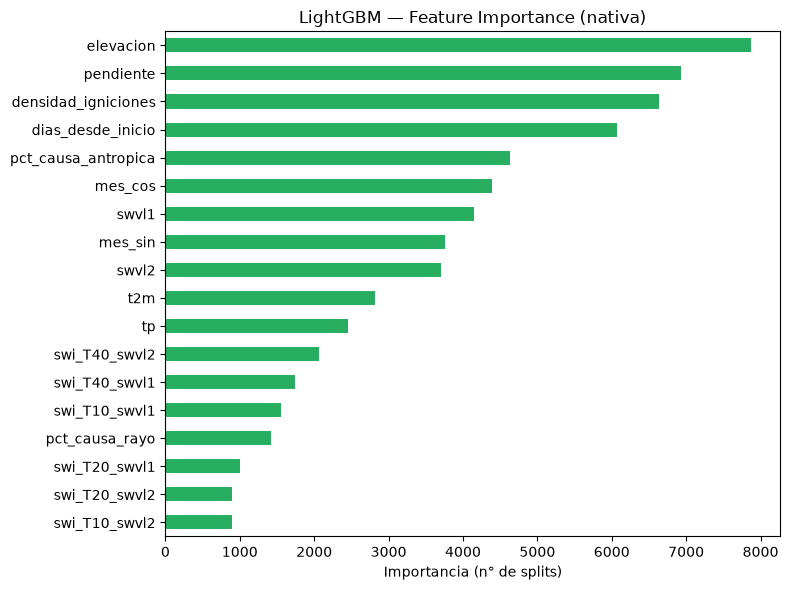

LIGHTGBM — TOP 5 VARIABLES
elevacion              7868
pendiente              6933
densidad_igniciones    6632
dias_desde_inicio      6075
pct_causa_antropica    4637
dtype: int32


In [60]:
# ============================================================
# FEATURE IMPORTANCE NATIVA
# ============================================================
importancias_lgbm = pd.Series(modelo_lgbm_final.feature_importances_, index=FEATURES_BASE).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importancias_lgbm.plot(kind="barh", ax=ax, color="#27ae60")
ax.invert_yaxis()
ax.set_title("LightGBM — Feature Importance (nativa)")
ax.set_xlabel("Importancia (n° de splits)")
plt.tight_layout()
plt.show()

print_header("LIGHTGBM — TOP 5 VARIABLES")
print(importancias_lgbm.head(5))

LIGHTGBM — RECALL TOP-K% (HOLDOUT 2021)
Top 0.1%: recall mediana=0.0000  IC95%=[0.0000, 0.0000]
Top 0.5%: recall mediana=0.0000  IC95%=[0.0000, 0.0000]
Top 1%: recall mediana=0.1141  IC95%=[0.0817, 0.1534]
Top 2%: recall mediana=0.3193  IC95%=[0.2757, 0.3704]
Top 5%: recall mediana=0.6508  IC95%=[0.6032, 0.6953]


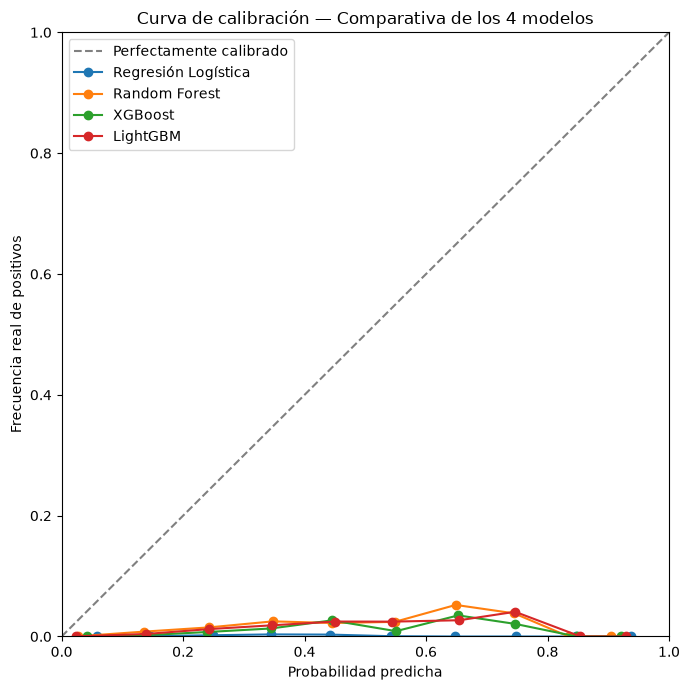

In [61]:
# ============================================================
# DIAGNÓSTICOS — RECALL@TOP-K% Y CALIBRACIÓN
# ============================================================
print_header("LIGHTGBM — RECALL TOP-K% (HOLDOUT 2021)")
for p in [0.1, 0.5, 1, 2, 5]:
    ic = recall_en_top_k_bootstrap(proba_test_lgbm, holdout["y_test"].values, p)
    print(f"Top {p}%: recall mediana={ic[1]:.4f}  IC95%=[{ic[0]:.4f}, {ic[2]:.4f}]")

prob_true_lgbm, prob_pred_lgbm = calibration_curve(holdout["y_test"], proba_test_lgbm, n_bins=10)

fig, ax = plt.subplots(figsize=(7,7))
ax.plot([0,1],[0,1], "--", color="gray", label="Perfectamente calibrado")
ax.plot(prob_pred, prob_true, marker="o", label="Regresión Logística")
ax.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")
ax.plot(prob_pred_xgb, prob_true_xgb, marker="o", label="XGBoost")
ax.plot(prob_pred_lgbm, prob_true_lgbm, marker="o", label="LightGBM")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Frecuencia real de positivos")
ax.set_title("Curva de calibración — Comparativa de los 4 modelos")
ax.legend()
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout()
plt.show()

In [62]:
# ============================================================
# DIAGNÓSTICO — LIGHTGBM EN HOLDOUT 2021
# ¿Colapso del modelo o del umbral?
# ============================================================
print_header("LIGHTGBM — DIAGNÓSTICO HOLDOUT 2021")

# Distribución general de probabilidades
print("Distribución de probabilidades predichas:")
for p in [50, 90, 95, 99, 99.5, 99.9, 100]:
    print(f"  p{p:5.1f}: {np.percentile(proba_test_lgbm, p):.4f}")

print(f"\nUmbral walk-forward: {umbral_lgbm_final:.4f}")
pct_supera = 100 * (proba_test_lgbm >= umbral_lgbm_final).mean()
print(f"% observaciones 2021 por encima del umbral: {pct_supera:.4f}%")

# Distribución específica de los positivos reales
proba_positivos_lgbm = proba_test_lgbm[holdout["y_test"].values == 1]

print("\nProbabilidades asignadas a los positivos reales:")
for p in [50, 75, 90, 95, 99, 100]:
    print(
        f"  p{p:5.1f}: "
        f"{np.percentile(proba_positivos_lgbm, p):.4f}")

print(f"\nMáxima probabilidad entre positivos reales: {proba_positivos_lgbm.max():.4f}")
print(
    f"Positivos reales por encima del umbral: "
    f"{(proba_positivos_lgbm >= umbral_lgbm_final).sum()} "
    f"de {len(proba_positivos_lgbm)}")

LIGHTGBM — DIAGNÓSTICO HOLDOUT 2021
Distribución de probabilidades predichas:
  p 50.0: 0.0196
  p 90.0: 0.0993
  p 95.0: 0.1840
  p 99.0: 0.7047
  p 99.5: 0.8284
  p 99.9: 0.9255
  p100.0: 0.9593

Umbral walk-forward: 0.7959
% observaciones 2021 por encima del umbral: 0.6130%

Probabilidades asignadas a los positivos reales:
  p 50.0: 0.2831
  p 75.0: 0.5402
  p 90.0: 0.7098
  p 95.0: 0.7367
  p 99.0: 0.7717
  p100.0: 0.7853

Máxima probabilidad entre positivos reales: 0.7853
Positivos reales por encima del umbral: 0 de 398


In [63]:
# ============================================================
# RECÁLCULO DE IMPORTANCIA — importance_type='gain'
# Para comparabilidad real con RF/XGBoost (evita el sesgo de
# 'split' hacia variables continuas con muchos valores únicos)
# ============================================================
modelo_lgbm_gain = lgb.LGBMClassifier(
    **mejores_params_lgbm,
    scale_pos_weight=scale_pos_weight_wf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
    importance_type="gain",
)
modelo_lgbm_gain.fit(X_wf, y_wf)

importancias_lgbm_gain = pd.Series(
    modelo_lgbm_gain.feature_importances_, index=FEATURES_BASE
).sort_values(ascending=False)

print_header("LIGHTGBM — TOP 5 VARIABLES (importance_type='gain')")
print(importancias_lgbm_gain.head(5))

LIGHTGBM — TOP 5 VARIABLES (importance_type='gain')
densidad_igniciones    4.884658e+07
swvl1                  2.451855e+07
dias_desde_inicio      2.450352e+07
pendiente              1.219299e+07
elevacion              1.185564e+07
dtype: float64


# COMPARATIVA FINAL

## Tabla comparativa — Walk-forward


Una vez entrenados y evaluados los cuatro modelos, se comparan bajo un mismo protocolo de validación temporal

La evaluación walk-forward permite medir el comportamiento de los modelos a lo largo del período 2016–2020, respetando la estructura temporal del problema. El objetivo no es únicamente identificar el modelo con mayor rendimiento medio, sino también observar su estabilidad entre años

In [64]:
# ============================================================
# COMPARATIVA FINAL — WALK-FORWARD
# ============================================================
resumen_wf = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "PR-AUC": [
        df_baseline["PR-AUC"].mean(),
        df_rf_wf["PR-AUC"].mean(),
        df_xgb_wf["PR-AUC"].mean(),
        df_lgbm_wf["PR-AUC"].mean()
    ],
    "ROC-AUC": [
        df_baseline["ROC-AUC"].mean(),
        df_rf_wf["ROC-AUC"].mean(),
        df_xgb_wf["ROC-AUC"].mean(),
        df_lgbm_wf["ROC-AUC"].mean()
    ],
    "Recall": [
        df_baseline["Recall"].mean(),
        df_rf_wf["Recall"].mean(),
        df_xgb_wf["Recall"].mean(),
        df_lgbm_wf["Recall"].mean()
    ],
    "Precision": [
        df_baseline["Precision"].mean(),
        df_rf_wf["Precision"].mean(),
        df_xgb_wf["Precision"].mean(),
        df_lgbm_wf["Precision"].mean()
    ],
    "F1": [
        df_baseline["F1"].mean(),
        df_rf_wf["F1"].mean(),
        df_xgb_wf["F1"].mean(),
        df_lgbm_wf["F1"].mean()
    ],
})

print_header("COMPARATIVA FINAL — WALK-FORWARD")
display(resumen_wf.round(4))

COMPARATIVA FINAL — WALK-FORWARD


,Modelo,PR-AUC,ROC-AUC,Recall,Precision,F1
0,Regresión Logística,0.0425,0.7709,0.5354,0.0277,0.0525
1,Random Forest,0.1150,0.8460,0.3037,0.1467,0.1931
2,XGBoost,0.1280,0.8358,0.5370,0.0739,0.1268
3,LightGBM,0.1339,0.8525,0.5305,0.0790,0.1349


In [65]:
# ============================================================
# VARIABILIDAD ENTRE FOLDS
# ============================================================
resumen_wf_std = pd.DataFrame({
    "Modelo": resumen_wf["Modelo"],
    "PR-AUC media ± std": [
        f"{df_baseline['PR-AUC'].mean():.4f} ± {df_baseline['PR-AUC'].std():.4f}",
        f"{df_rf_wf['PR-AUC'].mean():.4f} ± {df_rf_wf['PR-AUC'].std():.4f}",
        f"{df_xgb_wf['PR-AUC'].mean():.4f} ± {df_xgb_wf['PR-AUC'].std():.4f}",
        f"{df_lgbm_wf['PR-AUC'].mean():.4f} ± {df_lgbm_wf['PR-AUC'].std():.4f}",
    ],
    "ROC-AUC media ± std": [
        f"{df_baseline['ROC-AUC'].mean():.4f} ± {df_baseline['ROC-AUC'].std():.4f}",
        f"{df_rf_wf['ROC-AUC'].mean():.4f} ± {df_rf_wf['ROC-AUC'].std():.4f}",
        f"{df_xgb_wf['ROC-AUC'].mean():.4f} ± {df_xgb_wf['ROC-AUC'].std():.4f}",
        f"{df_lgbm_wf['ROC-AUC'].mean():.4f} ± {df_lgbm_wf['ROC-AUC'].std():.4f}",
    ]
})

display(resumen_wf_std)

,Modelo,PR-AUC media ± std,ROC-AUC media ± std
0,Regresión Logística,0.0425 ± 0.0396,0.7709 ± 0.0505
1,Random Forest,0.1150 ± 0.0496,0.8460 ± 0.0642
2,XGBoost,0.1280 ± 0.0582,0.8358 ± 0.0643
3,LightGBM,0.1339 ± 0.0603,0.8525 ± 0.0640


## Tabla comparativa — Holdout 2021

El conjunto de 2021 se mantuvo completamente separado del proceso de entrenamiento, la selección de hiperparámetros y la selección del umbral de decisión. Su rendimiento se utilizó, junto con los resultados del walk-forward, como criterio para la selección del modelo definitivo (sección siguiente); por tanto, no debe interpretarse como una estimación de generalización completamente independiente del proceso de selección de modelo, sino como el periodo de evaluación temporal sobre el cual se combinaron ambos criterios.

In [66]:
# ============================================================
# COMPARATIVA FINAL — HOLDOUT 2021
# ============================================================
resumen_holdout = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "PR-AUC": [
        metricas_holdout_calibrado["PR-AUC"],
        metricas_rf_holdout["PR-AUC"],
        metricas_xgb_holdout["PR-AUC"],
        metricas_lgbm_holdout["PR-AUC"]
    ],
    "ROC-AUC": [
        metricas_holdout_calibrado["ROC-AUC"],
        metricas_rf_holdout["ROC-AUC"],
        metricas_xgb_holdout["ROC-AUC"],
        metricas_lgbm_holdout["ROC-AUC"]
    ],
    "Recall": [
        metricas_holdout_calibrado["Recall"],
        metricas_rf_holdout["Recall"],
        metricas_xgb_holdout["Recall"],
        metricas_lgbm_holdout["Recall"]
    ],
    "Precision": [
       metricas_holdout_calibrado["Precision"],
        metricas_rf_holdout["Precision"],
        metricas_xgb_holdout["Precision"],
        metricas_lgbm_holdout["Precision"]
    ],
    "F1": [
        metricas_holdout["F1"],
        metricas_rf_holdout["F1"],
        metricas_xgb_holdout["F1"],
        metricas_lgbm_holdout["F1"]
    ]
})

print_header("COMPARATIVA FINAL — HOLDOUT 2021")
display(resumen_holdout.round(4))

COMPARATIVA FINAL — HOLDOUT 2021


,Modelo,PR-AUC,ROC-AUC,Recall,Precision,F1
0,Regresión Logística,0.0022,0.7123,0.0000,0.0000,0.0004
1,Random Forest,0.0218,0.9135,0.1558,0.0363,0.0589
2,XGBoost,0.0116,0.8944,0.0352,0.0058,0.0099
3,LightGBM,0.0149,0.9120,0.0000,0.0000,0.0000


## Curvas Precision-Recall

Debido al fuerte desequilibrio de clases, la curva Precision-Recall resulta especialmente informativa. Permite comparar la capacidad de los modelos para recuperar incendios manteniendo una precisión razonable. La línea horizontal representa la prevalencia de la clase positiva en el holdout.

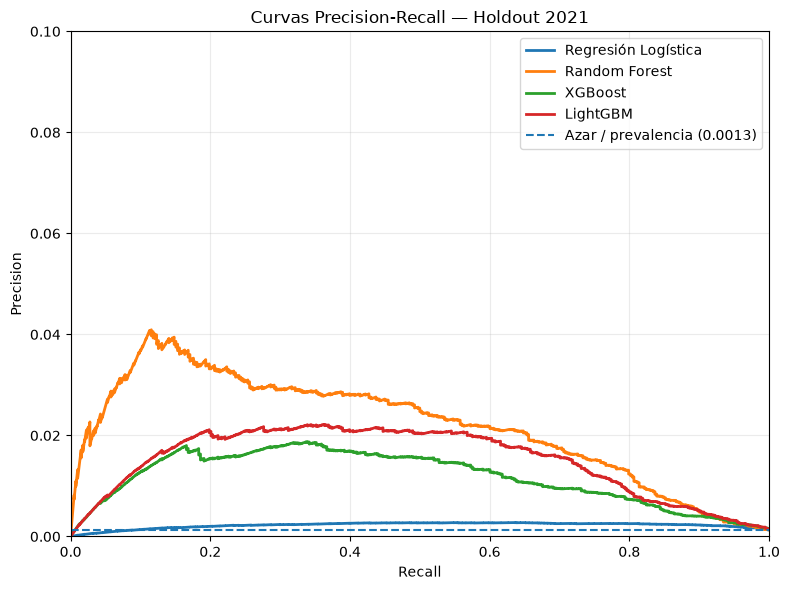

In [67]:
# ============================================================
# CURVAS PRECISION-RECALL — HOLDOUT 2021
# ============================================================
y_test = holdout["y_test"].values

modelos_proba = {
    "Regresión Logística": proba_test,
    "Random Forest": proba_test_rf,
    "XGBoost": proba_test_xgb,
    "LightGBM": proba_test_lgbm,
}

fig, ax = plt.subplots(figsize=(8, 6))

for nombre, proba in modelos_proba.items():
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=nombre
    )

prevalencia = y_test.mean()

ax.axhline(
    prevalencia,
    linestyle="--",
    linewidth=1.5,
    label=f"Azar / prevalencia ({prevalencia:.4f})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curvas Precision-Recall — Holdout 2021")
ax.set_xlim(0, 1)
ax.set_ylim(0, 0.1)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Curvas ROC

Las curvas ROC muestran la capacidad discriminativa global de los modelos independientemente del umbral seleccionado.
Aunque el ROC-AUC resulta útil como medida complementaria, su interpretación debe realizarse junto con PR-AUC debido al fuerte desequilibrio de clases.

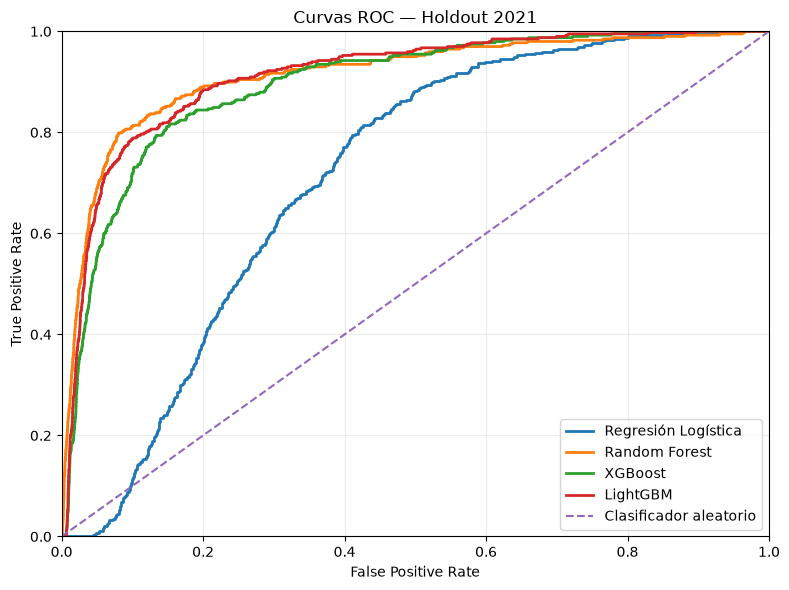

In [68]:
# ============================================================
# CURVAS ROC — HOLDOUT 2021
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

for nombre, proba in modelos_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=nombre
    )

ax.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1.5,
    label="Clasificador aleatorio"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC — Holdout 2021")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Recall@Top-K%



En un escenario operativo no es necesario clasificar toda la superficie como positiva. Una aplicación más realista consiste en priorizar el porcentaje de celdas con mayor riesgo estimado.

Recall@Top-K% mide qué proporción de los incendios reales se encuentra dentro del K% de observaciones con mayor probabilidad predicha.

In [69]:
# ============================================================
# RECALL@TOP-K% — HOLDOUT 2021
# ============================================================
top_k = [0.1, 0.5, 1, 2, 5]
resultados_topk = []

for nombre, proba in modelos_proba.items():
    for p in top_k:
        ic = recall_en_top_k_bootstrap(
            proba,
            y_test,
            p
        )

        resultados_topk.append({
            "Modelo": nombre,
            "Top-K (%)": p,
            "Recall": ic[1],
            "IC95_inf": ic[0],
            "IC95_sup": ic[2]
        })

df_topk = pd.DataFrame(resultados_topk)

print_header("RECALL@TOP-K% — HOLDOUT 2021")
display(
    df_topk
    .pivot(index="Top-K (%)", columns="Modelo", values="Recall")
    .round(4)
)

RECALL@TOP-K% — HOLDOUT 2021


Modelo,LightGBM,Random Forest,Regresión Logística,XGBoost
Top-K (%),,,,
0.1,0.0000,0.0079,0.0000,0.0000
0.5,0.0000,0.1454,0.0000,0.0000
1.0,0.1141,0.2385,0.0000,0.0763
2.0,0.3193,0.4207,0.0000,0.2384
5.0,0.6508,0.6830,0.0074,0.5479


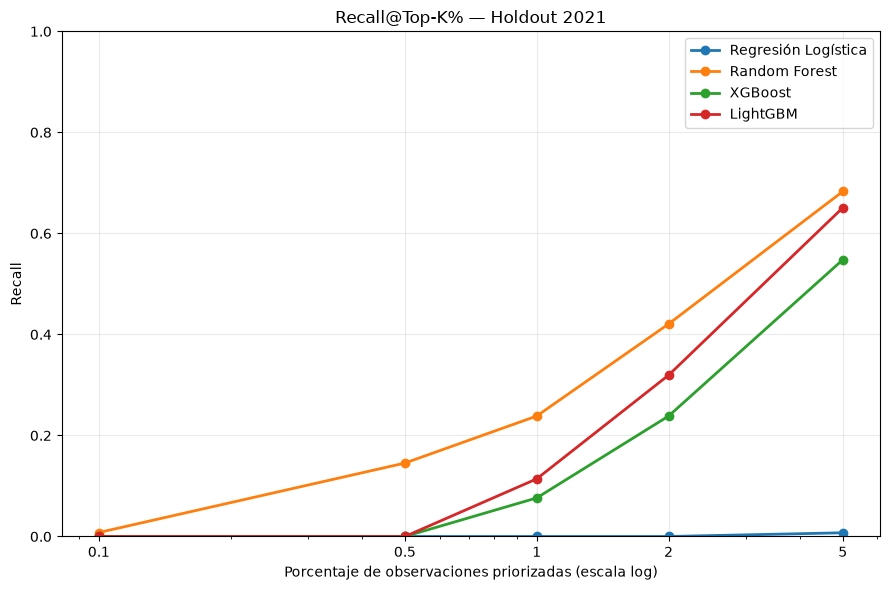

In [70]:
# ============================================================
# GRÁFICO RECALL@TOP-K%
# ============================================================
fig, ax = plt.subplots(figsize=(9, 6))

for nombre in modelos_proba.keys():
    datos = df_topk[df_topk["Modelo"] == nombre]
    ax.plot(
        datos["Top-K (%)"],
        datos["Recall"],
        marker="o",
        linewidth=2,
        label=nombre
    )

ax.set_xscale("log")
ax.set_xlabel("Porcentaje de observaciones priorizadas (escala log)")
ax.set_ylabel("Recall")
ax.set_title("Recall@Top-K% — Holdout 2021")
ax.set_xticks(top_k)
ax.set_xticklabels([str(x) for x in top_k])
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Estabilidad frente a un posible dataset shift

El rendimiento walk-forward representa el comportamiento esperado dentro del período utilizado para el desarrollo del modelo, mientras que 2021 constituye un período completamente no observado.

Para evaluar la robustez temporal se calcula la conservación relativa del PR-AUC: Una mayor conservación indica una menor degradación relativa al pasar del período de desarrollo al holdout.

In [71]:
# ============================================================
# ESTABILIDAD WALK-FORWARD → HOLDOUT
# ============================================================
resumen_estabilidad = pd.DataFrame({
    "Modelo": resumen_wf["Modelo"],
    "PR-AUC WF": resumen_wf["PR-AUC"],
    "PR-AUC 2021": resumen_holdout["PR-AUC"]
    })

resumen_estabilidad["Caída relativa (%)"] = (100 * (1 - resumen_estabilidad["PR-AUC 2021"] / resumen_estabilidad["PR-AUC WF"]))
resumen_estabilidad["Conservación (%)"] = (100 * resumen_estabilidad["PR-AUC 2021"] / resumen_estabilidad["PR-AUC WF"])
resumen_estabilidad["Lift 2021"] = (resumen_estabilidad["PR-AUC 2021"] / y_test.mean())

print_header("ESTABILIDAD FRENTE AL DATASET SHIFT")
display(resumen_estabilidad.round(4))

ESTABILIDAD FRENTE AL DATASET SHIFT


,Modelo,PR-AUC WF,PR-AUC 2021,Caída relativa (%),Conservación (%),Lift 2021
0,Regresión Logística,0.0425,0.0022,94.7623,5.2377,1.6693
1,Random Forest,0.1150,0.0218,81.0153,18.9847,16.3572
2,XGBoost,0.1280,0.0116,90.9281,9.0719,8.6996
3,LightGBM,0.1339,0.0149,88.8757,11.1243,11.1623


In [72]:
# ============================================================
# TABLA FINAL PARA LA SELECCIÓN
# ============================================================
seleccion_modelos = resumen_estabilidad.copy()

seleccion_modelos["ROC-AUC 2021"] = resumen_holdout["ROC-AUC"].values
seleccion_modelos["Recall 2021"] = resumen_holdout["Recall"].values
seleccion_modelos["Precision 2021"] = resumen_holdout["Precision"].values
seleccion_modelos["F1 2021"] = resumen_holdout["F1"].values

print_header("CRITERIOS PARA LA SELECCIÓN DEL MODELO")
display(seleccion_modelos.round(4))

CRITERIOS PARA LA SELECCIÓN DEL MODELO


,Modelo,PR-AUC WF,PR-AUC 2021,Caída relativa (%),Conservación (%),Lift 2021,ROC-AUC 2021,Recall 2021,Precision 2021,F1 2021
0,Regresión Logística,0.0425,0.0022,94.7623,5.2377,1.6693,0.7123,0.0000,0.0000,0.0004
1,Random Forest,0.1150,0.0218,81.0153,18.9847,16.3572,0.9135,0.1558,0.0363,0.0589
2,XGBoost,0.1280,0.0116,90.9281,9.0719,8.6996,0.8944,0.0352,0.0058,0.0099
3,LightGBM,0.1339,0.0149,88.8757,11.1243,11.1623,0.9120,0.0000,0.0000,0.0000


La comparación entre la regresión logística, Random Forest, XGBoost y LightGBM muestra una mejora clara de los modelos basados en árboles respecto al baseline lineal, tanto en walk-forward como en el periodo de evaluación temporal 2021.

**Criterio de selección del modelo definitivo**: la selección se basó en el rendimiento combinado sobre el alk-forward (2016-2020) y el periodo de evaluación temporal 2021, priorizando este último por representar el escenario más cercano a un despliegue real ante un año no observado durante el desarrollo. Se declara explícitamente que 2021 participó en esta decisión; por tanto, las métricas reportadas sobre dicho periodo para el modelo seleccionado no constituyen una estimación de generalización completamente independiente del proceso de selección.

Aunque LightGBM obtuvo el mejor PR-AUC medio en walk-forward (0.134 frente a 0.115 de Random Forest), su rendimiento se degrada de forma más pronunciada en 2021 (recall=0.000 con el umbral seleccionado sin fuga, frente a 0.158 de Random Forest). Random Forest presenta la menor caída relativa de PR-AUC entre ambos periodos y es el único modelo de árboles que conserva un rendimiento no nulo en 2021 con el umbral seleccionado mediante el procedimiento sin fuga de información. Por estas razones, se selecciona Random Forest como modelo definitivo del estudio.

Los resultados deben interpretarse como un sistema de priorización relativa del riesgo y no como probabilidades absolutas perfectamente calibradas.

In [73]:
# ============================================================
# EXPORTACIÓN — MODELO DEFINITIVO (Random Forest) + ARTEFACTOS
# NECESARIOS PARA 05_INTERPRETABILIDAD
# ============================================================
RUTA_MODELOS = Path("modelos")
RUTA_MODELOS.mkdir(exist_ok=True)

# El modelo entrenado (objeto completo, listo para .predict/.predict_proba) ---
joblib.dump(modelo_rf_final, RUTA_MODELOS / "rf_final.joblib")

# Metadatos necesarios para reproducir predicciones sin reentrenar ---
metadata_rf = {
    "features": FEATURES_BASE,
    "target": TARGET,
    "mejores_hiperparametros": mejores_params_rf,
    "class_weight": {str(k): v for k, v in class_weight_wf.items()},  # keys a str para JSON
    "umbral_decision": float(umbral_rf_final),
    "periodo_train": "2008-2020",
    "periodo_holdout": "2021",
    "metricas_holdout": {k: float(v) for k, v in metricas_rf_holdout.items()},
}
with open(RUTA_MODELOS / "rf_final_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata_rf, f, indent=2, ensure_ascii=False)

print_header("EXPORTACIÓN — RANDOM FOREST (MODELO DEFINITIVO)")
print(f"Modelo guardado en: {RUTA_MODELOS / 'rf_final.joblib'}")
print(f"Metadata guardada en: {RUTA_MODELOS / 'rf_final_metadata.json'}")
print(f"\numbral_decision: {umbral_rf_final:.4f}")
print(f"features: {len(FEATURES_BASE)} variables")

EXPORTACIÓN — RANDOM FOREST (MODELO DEFINITIVO)
Modelo guardado en: modelos\rf_final.joblib
Metadata guardada en: modelos\rf_final_metadata.json

umbral_decision: 0.5782
features: 18 variables


In [74]:
# ============================================================
# RE-EXPORTACIÓN — HOLDOUT CON COORDENADAS (para análisis espacial en 05)
# Las columnas latitude/longitude/time se añaden como METADATOS
# de identificación, NO como features del modelo (FEATURES_BASE
# no cambia). Necesarias para el bloque de interpretabilidad
# espacial de 05_interpretabilidad.ipynb.
# ============================================================

holdout["X_test"].assign(
    target_incendio=holdout["y_test"].values,
    latitude=df.loc[holdout["X_test"].index, "latitude"].values,
    longitude=df.loc[holdout["X_test"].index, "longitude"].values,
    time=df.loc[holdout["X_test"].index, "time"].values,
).to_parquet(RUTA_MODELOS / "holdout_test.parquet", index=False)

print(f"Holdout re-exportado con coordenadas: {RUTA_MODELOS / 'holdout_test.parquet'}")
print(f"Columnas: {list(holdout['X_test'].columns) + ['target_incendio', 'latitude', 'longitude', 'time']}")

Holdout re-exportado con coordenadas: modelos\holdout_test.parquet
Columnas: ['swvl1', 'swvl2', 't2m', 'tp', 'swi_T10_swvl1', 'swi_T10_swvl2', 'swi_T20_swvl1', 'swi_T20_swvl2', 'swi_T40_swvl1', 'swi_T40_swvl2', 'elevacion', 'pendiente', 'densidad_igniciones', 'pct_causa_antropica', 'pct_causa_rayo', 'dias_desde_inicio', 'mes_sin', 'mes_cos', 'target_incendio', 'latitude', 'longitude', 'time']


In [75]:
# Verificación previa — confirmar alineación de índices antes de exportar
assert holdout["X_test"].index.equals(
    df.loc[holdout["X_test"].index].index
), "⚠ Los índices no se alinean como se esperaba — revisar antes de exportar"

muestra_check = df.loc[holdout["X_test"].index[:5], ["latitude", "longitude", "target_incendio"]]
print("Verificación manual — primeras 5 filas:")
print(muestra_check)
print("\nComparar target_incendio aquí contra holdout['y_test'].values[:5]:")
print(holdout["y_test"].values[:5])

Verificación manual — primeras 5 filas:
          latitude  longitude  target_incendio
3879933  43.601418  -7.885475                0
3879934  43.601418  -7.635475                0
3879935  43.351418  -8.135475                0
3879936  43.351418  -7.885475                0
3879937  43.351418  -7.635475                0

Comparar target_incendio aquí contra holdout['y_test'].values[:5]:
[0 0 0 0 0]


In [76]:
# ============================================================
# EXPORTACIÓN LIGERA — RESULTADOS COMPARATIVOS DE LOS OTROS 3 MODELOS
# Solo resultados ya calculados, para una eventual figura de robustez en 05 sin cargar objetos pesados.
# ============================================================

comparativa_ligera = {
    "importancias": {
        "rf": importancias_rf.to_dict(),
        "xgb": importancias_xgb.to_dict(),
        "lgbm_gain": importancias_lgbm_gain.to_dict(),
    },
    "calibracion": {
        "logistica":  {"prob_pred": prob_pred.tolist(),      "prob_true": prob_true.tolist()},
        "rf":         {"prob_pred": prob_pred_rf.tolist(),   "prob_true": prob_true_rf.tolist()},
        "xgb":        {"prob_pred": prob_pred_xgb.tolist(),  "prob_true": prob_true_xgb.tolist()},
        "lgbm":       {"prob_pred": prob_pred_lgbm.tolist(), "prob_true": prob_true_lgbm.tolist()},
    },
    "metricas_holdout": {
        "logistica": {k: float(v) for k, v in metricas_holdout_calibrado.items()},
        "rf":        {k: float(v) for k, v in metricas_rf_holdout.items()},
        "xgb":       {k: float(v) for k, v in metricas_xgb_holdout.items()},
        "lgbm":      {k: float(v) for k, v in metricas_lgbm_holdout.items()},
    },
}

with open(RUTA_MODELOS / "comparativa_4_modelos.json", "w", encoding="utf-8") as f:
    json.dump(comparativa_ligera, f, indent=2, ensure_ascii=False)

print(f"Comparativa ligera guardada: {RUTA_MODELOS / 'comparativa_4_modelos.json'}")

Comparativa ligera guardada: modelos\comparativa_4_modelos.json


# MODELO RF PROXY

In [77]:
# ============================================================
# EXPORTACIÓN — MODELO PROXY PARA INTERPRETABILIDAD (SHAP)
# El modelo definitivo (300 árboles, profundidad 25) resultó
# computacionalmente inviable para TreeSHAP exacto (~11 s/fila,
# ver benchmark en 05_interpretabilidad). Se entrena aquí un RF
# más superficial, sobre los MISMOS datos y misma ponderación de
# clase, exclusivamente para servir de base a SHAP. El modelo
# reportado como resultado de rendimiento sigue siendo
# modelo_rf_final — este proxy NUNCA sustituye esas métricas.
# ============================================================
modelo_rf_proxy = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=50,
    max_features="sqrt",
    class_weight=class_weight_wf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
modelo_rf_proxy.fit(X_wf, y_wf)

# Validación de fidelidad del proxy respecto al definitivo
proba_proxy = modelo_rf_proxy.predict_proba(holdout["X_test"])[:, 1]
proba_definitivo = modelo_rf_final.predict_proba(holdout["X_test"])[:, 1]

pr_auc_proxy = average_precision_score(holdout["y_test"], proba_proxy)
roc_auc_proxy = roc_auc_score(holdout["y_test"], proba_proxy)
correlacion_proxy = np.corrcoef(proba_proxy, proba_definitivo)[0, 1]

# Overlap en el top-k del ranking — ¿el proxy prioriza las mismas celdas-día?
def overlap_top_k(proba_a, proba_b, k_pct):
    n = len(proba_a)
    k = int(n * k_pct / 100)
    top_a = set(np.argsort(-proba_a)[:k])
    top_b = set(np.argsort(-proba_b)[:k])
    return len(top_a & top_b) / k

overlap_1pct = overlap_top_k(proba_proxy, proba_definitivo, 1)
overlap_5pct = overlap_top_k(proba_proxy, proba_definitivo, 5)

validacion_proxy = {
    "pr_auc_proxy": float(pr_auc_proxy),
    "pr_auc_definitivo": float(metricas_rf_holdout["PR-AUC"]),
    "roc_auc_proxy": float(roc_auc_proxy),
    "roc_auc_definitivo": float(metricas_rf_holdout["ROC-AUC"]),
    "correlacion_probabilidades": float(correlacion_proxy),
    "overlap_top_1pct": float(overlap_1pct),
    "overlap_top_5pct": float(overlap_5pct),
    "hiperparametros_proxy": {
        "n_estimators": 100, "max_depth": 8, "min_samples_leaf": 50, "max_features": "sqrt"
    },
}

print_header("VALIDACIÓN DEL MODELO PROXY")
for k, v in validacion_proxy.items():
    if not isinstance(v, dict):
        print(f"{k:30s}: {v:.4f}" if isinstance(v, float) else f"{k:30s}: {v}")


VALIDACIÓN DEL MODELO PROXY
pr_auc_proxy                  : 0.0066
pr_auc_definitivo             : 0.0218
roc_auc_proxy                 : 0.8366
roc_auc_definitivo            : 0.9135
correlacion_probabilidades    : 0.6772
overlap_top_1pct              : 0.6194
overlap_top_5pct              : 0.5452


In [78]:
# ============================================================
# BÚSQUEDA DE PROFUNDIDAD ÓPTIMA PARA EL PROXY
# El proxy con max_depth=8 fue insuficiente (correlación=0.68,
# criterio mínimo=0.85). Se prueban profundidades intermedias,
# midiendo fidelidad Y tiempo estimado de SHAP en cada una, para
# encontrar el mayor max_depth que siga siendo computacionalmente
# tratable.
# ============================================================
profundidades_a_probar = [10, 12, 14, 16]
resultados_busqueda = []

for depth in profundidades_a_probar:
    modelo_prueba = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        min_samples_leaf=30,
        max_features="sqrt",
        class_weight=class_weight_wf,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    modelo_prueba.fit(X_wf, y_wf)

    proba_prueba = modelo_prueba.predict_proba(holdout["X_test"])[:, 1]
    corr = np.corrcoef(proba_prueba, proba_definitivo)[0, 1]
    pr_auc_prueba = average_precision_score(holdout["y_test"], proba_prueba)
    overlap_5 = overlap_top_k(proba_prueba, proba_definitivo, 5)
    overlap_1 = overlap_top_k(proba_prueba, proba_definitivo, 1)

    resultados_busqueda.append({
        "max_depth": depth, "correlacion": corr,
        "pr_auc": pr_auc_prueba, "overlap_top5": overlap_5,
        "overlap_top1": overlap_1
    })
    print(f"max_depth={depth:2d}: correlación={corr:.4f} | PR-AUC={pr_auc_prueba:.4f} | overlap_top5={overlap_5:.4f} | overlap_top1={overlap_1:.4f}")

df_busqueda_proxy = pd.DataFrame(resultados_busqueda)
display(df_busqueda_proxy)

max_depth=10: correlación=0.7707 | PR-AUC=0.0100 | overlap_top5=0.6424 | overlap_top1=0.7183
max_depth=12: correlación=0.8573 | PR-AUC=0.0141 | overlap_top5=0.7487 | overlap_top1=0.7897
max_depth=14: correlación=0.9100 | PR-AUC=0.0177 | overlap_top5=0.8026 | overlap_top1=0.8320
max_depth=16: correlación=0.9487 | PR-AUC=0.0195 | overlap_top5=0.8559 | overlap_top1=0.8645


,max_depth,correlacion,pr_auc,overlap_top5,overlap_top1
0,10,0.770670,0.010049,0.642388,0.718310
1,12,0.857264,0.014148,0.748692,0.789738
2,14,0.910029,0.017739,0.802616,0.831992
3,16,0.948661,0.019489,0.855869,0.864520


El modelo proxy no se utiliza para evaluar capacidad predictiva ni para seleccionar el modelo definitivo. Su única finalidad es aproximar el comportamiento del Random Forest final para hacer viable el cálculo de SHAP. La fidelidad del proxy se evaluó mediante la correlación de las probabilidades predichas y el solapamiento de los principales casos priorizados.

La profundidad del proxy se seleccionó comparando su fidelidad (correlación de probabilidades y solapamiento del ranking) frente al modelo definitivo sobre el propio periodo de evaluación 2021. Esta selección, por tanto, no es independiente de dicho periodo; se declara explícitamente para evitar cualquier interpretación de "validación independiente" del proxy.

In [79]:
# ============================================================
# CRONOMETRAJE DE SHAP PARA LOS CANDIDATOS A PROXY (depth 12-16)
# El objetivo es encontrar el mayor max_depth que sea SIMULTÁNEAMENTE
# fiel (correlación ≥0.85) y tratable en tiempo razonable.
# ============================================================
for depth in [12, 14, 16]:
    modelo_candidato = RandomForestClassifier(
        n_estimators=100, max_depth=depth, min_samples_leaf=30,
        max_features="sqrt", class_weight=class_weight_wf,
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    modelo_candidato.fit(X_wf, y_wf)

    explainer_candidato = shap.TreeExplainer(modelo_candidato, feature_perturbation="tree_path_dependent")
    muestra_tiempo = holdout["X_test"].sample(n=10, random_state=42)

    t0 = time.time()
    _ = explainer_candidato.shap_values(muestra_tiempo[FEATURES_BASE])
    t1 = time.time()

    seg_por_fila = (t1 - t0) / 10
    print(f"max_depth={depth:2d}: {seg_por_fila:.3f} s/fila → "
          f"1.000 filas ≈ {seg_por_fila*1000/60:.1f} min | "
          f"5.000 filas ≈ {seg_por_fila*5000/60:.1f} min | "
          f"398 positivos ≈ {seg_por_fila*398/60:.1f} min")

max_depth=12: 0.090 s/fila → 1.000 filas ≈ 1.5 min | 5.000 filas ≈ 7.5 min | 398 positivos ≈ 0.6 min
max_depth=14: 0.198 s/fila → 1.000 filas ≈ 3.3 min | 5.000 filas ≈ 16.5 min | 398 positivos ≈ 1.3 min
max_depth=16: 0.381 s/fila → 1.000 filas ≈ 6.3 min | 5.000 filas ≈ 31.7 min | 398 positivos ≈ 2.5 min


In [80]:
# ============================================================
# SELECCIÓN FINAL DEL MODELO PROXY PARA SHAP
# Se selecciona max_depth=16 por ofrecer el mejor compromiso
# entre fidelidad al RF definitivo y coste computacional.
# El proxy NO sustituye al modelo definitivo ni sus métricas.
# Su profundidad se seleccionó usando el periodo de evaluación 2021
# como criterio de fidelidad — no es una selección independiente de
# dicho periodo (ver nota metodológica en la celda anterior).
# ============================================================
PROXY_PARAMS = {
    "n_estimators": 100,
    "max_depth": 16,
    "min_samples_leaf": 30,
    "max_features": "sqrt",
    "class_weight": class_weight_wf,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

modelo_rf_proxy = RandomForestClassifier(**PROXY_PARAMS)
modelo_rf_proxy.fit(X_wf, y_wf)
print_header("MODELO PROXY — SELECCIÓN FINAL")
print("Modelo definitivo:")
print("  n_estimators = 300")
print("  max_depth    = 25")
print("\nModelo proxy:")
for k, v in PROXY_PARAMS.items():
    if k != "class_weight":
        print(f"  {k:20s}: {v}")

MODELO PROXY — SELECCIÓN FINAL
Modelo definitivo:
  n_estimators = 300
  max_depth    = 25

Modelo proxy:
  n_estimators        : 100
  max_depth           : 16
  min_samples_leaf    : 30
  max_features        : sqrt
  random_state        : 42
  n_jobs              : -1


In [81]:
# ============================================================
# VALIDACIÓN FINAL DE FIDELIDAD DEL PROXY
# ============================================================
proba_proxy = modelo_rf_proxy.predict_proba(holdout["X_test"])[:, 1]
proba_definitivo = modelo_rf_final.predict_proba(holdout["X_test"])[:, 1]
correlacion_proxy = np.corrcoef(proba_proxy, proba_definitivo)[0, 1]

pr_auc_proxy = average_precision_score(holdout["y_test"], proba_proxy)
roc_auc_proxy = roc_auc_score(holdout["y_test"],proba_proxy)

overlap_1pct = overlap_top_k(proba_proxy, proba_definitivo,1)
overlap_5pct = overlap_top_k(proba_proxy, proba_definitivo,5)

print_header("VALIDACIÓN FINAL — PROXY vs RF DEFINITIVO")
print(f"Correlación probabilidades : {correlacion_proxy:.4f}")
print(f"PR-AUC proxy               : {pr_auc_proxy:.4f}")
print(f"PR-AUC definitivo          : {metricas_rf_holdout['PR-AUC']:.4f}")
print(f"ROC-AUC proxy              : {roc_auc_proxy:.4f}")
print(f"ROC-AUC definitivo         : {metricas_rf_holdout['ROC-AUC']:.4f}")
print(f"Overlap Top-1%             : {overlap_1pct:.4f}")
print(f"Overlap Top-5%             : {overlap_5pct:.4f}")

VALIDACIÓN FINAL — PROXY vs RF DEFINITIVO
Correlación probabilidades : 0.9487
PR-AUC proxy               : 0.0195
PR-AUC definitivo          : 0.0218
ROC-AUC proxy              : 0.9079
ROC-AUC definitivo         : 0.9135
Overlap Top-1%             : 0.8645
Overlap Top-5%             : 0.8559


In [82]:
# Exportar el modelo proxy con joblib
joblib.dump(modelo_rf_proxy, RUTA_MODELOS / "rf_proxy_shap.joblib")
print(f"Modelo guardado en: {RUTA_MODELOS / 'rf_proxy_shap.joblib'}")

# Estructurar el diccionario de validación convirtiendo tipos de NumPy a nativos de Python
validacion_proxy = {
    "descripcion": "Modelo Proxy entrenado exclusivamente para la interpretación con SHAP",
    "parametros": {
        "n_estimators": int(PROXY_PARAMS["n_estimators"]),
        "max_depth": int(PROXY_PARAMS["max_depth"]),
        "min_samples_leaf": int(PROXY_PARAMS["min_samples_leaf"]),
        "max_features": str(PROXY_PARAMS["max_features"]),
        "random_state": int(PROXY_PARAMS["random_state"])
    },
    "metricas_fidelidad": {
        "correlacion_probabilidades": float(correlacion_proxy),
        "overlap_top_1pct": float(overlap_1pct),
        "overlap_top_5pct": float(overlap_5pct)
    },
    "metricas_rendimiento": {
        "pr_auc_proxy": float(pr_auc_proxy),
        "pr_auc_definitivo": float(metricas_rf_holdout['PR-AUC']),
        "roc_auc_proxy": float(roc_auc_proxy),
        "roc_auc_definitivo": float(metricas_rf_holdout['ROC-AUC'])
    }
}

# Exportar las métricas en formato JSON
with open(RUTA_MODELOS / "rf_proxy_validacion.json", "w", encoding="utf-8") as f:
    json.dump(validacion_proxy, f, indent=2, ensure_ascii=False)
print(f"Validación guardada en: {RUTA_MODELOS / 'rf_proxy_validacion.json'}")

Modelo guardado en: modelos\rf_proxy_shap.joblib
Validación guardada en: modelos\rf_proxy_validacion.json
